In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import matplotlib.patches as patches
import time

# Functions

In [2]:
def dneff_w(width, a, b):
    '''Function to model the variation of effective index with waveguide width.

    Inputs:
    - width: array of waveguide widths (um)
    - a, b: fitting parameters

    Outputs:
    - dneff: array of effective index variations corresponding to the input widths
    '''
    # Variation of effective index with waveguide width
    width_0 = 1.0
    dneff = a*(width - width_0)**2 + b*(width - width_0)
    return dneff

def neff_wl(wavelength, a, b, c):
    '''Function to model the variation of effective index with wavelength.

    Inputs:
    - wavelength: array of wavelengths (nm)
    - a, b, c: fitting parameters

    Outputs:
    - neff: array of effective indices corresponding to the input wavelengths
    '''
    # Variation of effective index with wavelength
    wl_0 = 1550
    neff = a - b*(wavelength - wl_0) - c*(wavelength - wl_0)**2
    return neff

def neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid):
    '''Function to model the effective index variation with wavelength and waveguide width.

    Inputs:
    - wavelength_train: array of training wavelengths (nm)
    - width_train: array of training waveguide widths (um)
    - dneff_train: array of training effective index variations
    - neff_train: array of training effective indices
    - width_test: array of test waveguide widths (um)
    - wavelength_test: array of test wavelengths (nm)
    - neff_valid: array of validation effective indices

    Outputs:
    - mse: mean squared error between predicted and validation effective indices
    - neff_test2: array of predicted effective indices for the test data
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    '''
    width_0 = 1.0
    wl_0 = 1550

    p0_w = [0, 0]
    limits_w = ([-np.inf, -np.inf], [np.inf, np.inf])
    popt_w, pcov_w = curve_fit(dneff_w, width_train, dneff_train, bounds = limits_w, p0=p0_w, maxfev = int(1e5))

    p0_wl = [1.54, 0, 0]
    limits_wl = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_wl, pcov_wl = curve_fit(neff_wl, wavelength_train, neff_train, bounds = limits_wl, p0=p0_wl, maxfev = int(1e5))

    neff_test = neff_wl(wavelength_train, *popt_wl) + dneff_w(width_test, *popt_w)
    mse = np.mean((neff_valid - neff_test)**2)

    neff_test2 = neff_wl(wavelength_test, *popt_wl) + dneff_w(width_test, *popt_w)

    # print(f'neff (λ [nm]) = {popt_wl[0]:.5f} - {popt_wl[1]:.5f}*(λ - {wl_0}) - ({popt_wl[2]:.5e}*(λ - {wl_0})^2)')
    # print(f'Δneff (w [μm]) = {popt_w[0]:.5f}*(w - {width_0})^2 + {popt_w[1]:.5f}*(w - {width_0})')

    return mse, neff_test2, popt_w, popt_wl

def open_file_modesolver(file_path, mode=0):
    ''' Function to open and read mode solver data from a file.

    Inputs:
    - file_path: path to the file containing mode solver data
    - mode: mode number to extract (default is 0, TE0 mode)

    Outputs:
    - wavelength: array of wavelengths
    - n_eff: array of effective indices
    '''
    with open(file_path, 'r') as f:
        first_line = f.readline()

    wl, index, neff = np.loadtxt(file_path, skiprows=1, usecols=(0, 1, 2), dtype=complex, unpack=True)
    filter = (index == mode)
    
    # Load wavelength and effective index
    wavelength, n_eff = wl[filter].real, neff[filter].real

    return wavelength, n_eff

def C_matrix(wavelength, neff, dz):
    '''Function to calculate the propagation matrix for a given wavelength, effective index, and step size.

    Inputs:
    - wavelength: wavelength of light (m)
    - neff: effective index of the waveguide
    - dz: step size along the waveguide (m)
    '''
    C = np.zeros((2, 2), dtype=complex)
    phase = 2*np.pi*neff/wavelength * dz
    C[0,0] = np.exp(1j * phase)
    C[1,1] = np.exp(-1j * phase)
    return C

def I_matrix(neff_1, neff_2):
    '''Function to calculate the interface matrix for two effective indices.
    
    Inputs:
    - neff_1: effective index of the first waveguide section
    - neff_2: effective index of the second waveguide section
    '''
    I = np.zeros((2, 2))
    I[0,0] = neff_1 + neff_2
    I[1,1] = I[0,0]
    I[0,1] = neff_2 - neff_1
    I[1,0] = I[0,1]
    I = (1/(2*np.sqrt(neff_1 * neff_2)))*I
    return I

def Bragg_grating(wavelength, w_array, dz, N, popt_wl, popt_w):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w)
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

def uniform_grating(period, dwidth_2, N, duty, dL):
    '''Function to generate a uniform grating with specified parameters.

    Inputs:
    - period: grating period (m)
    - dwidth_2: corrugation of the second section of the grating (m)
    - N: number of periods in the grating
    - duty: duty cycle of the grating (fraction of the period occupied by the first section)
    - dL: length of the grating (m)

    Outputs:
    - z_real: array of positions along the grating (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    '''
    resolution = 500*N # Number of points to represent the grating
    L = period*N
    
    z_real = np.linspace(0, L, resolution)
    dw_real_p = np.where((z_real % period) < (period*duty), 0.0, dwidth_2) # Width variations for the positive section
    dw_real_n = -np.where(((z_real - dL) % period) < (period*duty), 0.0, dwidth_2) # Width variations for the negative section
    return z_real, np.array(dw_real_p), np.array(dw_real_n)

def grating_geometry(z_real, w_real_p, w_real_n, M):
    '''Function to calculate the mean width of the grating in M steps along the z direction.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - w_real_p: array of width variations for the positive section of the grating (um)
    - w_real_n: array of width variations for the negative section of the grating (um)
    - M: number of steps to divide the grating into
    
    Outputs:
    - z_edges: array of edges of the M steps along the z direction (m)
    - w_mean_p: array of mean widths for the positive section of the grating in each step (um)
    - w_mean_n: array of mean widths for the negative section of the grating in each step (um)
    '''
    # Calculate the mean width of the grating in M steps along the z direction
    L = max(z_real)

    z_edges = np.linspace(0, L, M + 1) 
    w_mean_p = []
    w_mean_n = []
    z_center = []

    for i in range(M):
        z_min = z_edges[i]
        z_max = z_edges[i+1]
        
        mask = (z_real >= z_min) & (z_real < z_max)
        
        step_mean_width_p = np.mean(w_real_p[mask])
        w_mean_p.append(step_mean_width_p)

        step_mean_width_n = np.mean(w_real_n[mask])
        w_mean_n.append(step_mean_width_n)
        
        z_center.append((z_min + z_max) / 2)

    return z_edges, np.array(w_mean_p), np.array(w_mean_n)

def prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor):
    '''Function to apply a Gaussian filter to the grating width variations and scale by a loss factor.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - sigma: standard deviation of the Gaussian filter (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    - scale_factor: scaling factor to account for losses in the grating
    
    Outputs:
    - dw_fab_p: array of filtered and scaled width variations for the positive section of the grating (um)
    - dw_fab_n: array of filtered and scaled width variations for the negative section of the grating (um)
    '''
    dz = z_real[1] - z_real[0]

    z_kernel = np.arange(-4*sigma, 4*sigma, dz)
    gaussian_kernel = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-z_kernel**2/(2*sigma**2))
    gaussian_kernel /= np.sum(gaussian_kernel)

    dw_fab_p = np.convolve(dw_real_p, gaussian_kernel, mode='same')
    dw_fab_n = np.convolve(dw_real_n, gaussian_kernel, mode='same')

    dw_fab_p *= scale_factor
    dw_fab_n *= scale_factor

    return dw_fab_p, dw_fab_n

def find_minima(power, wavelength, threshold, separation):
    '''Function to find minima in the power spectrum.

    Inputs:
    - power: array of power values
    - wavelength: array of wavelength values
    - threshold: minimum prominence of the peaks
    - separation: minimum distance between peaks

    Outputs:
    - indices: array of indices of the found minima
    '''
    power_inverted = -power

    # Calculate average step size in wavelength and convert separation from nm to number of points based on average step size
    avg_step = np.mean(np.diff(wavelength)) 
    dist_points = int(separation/avg_step) 

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def find_minima_sides(wavelength, transmittance, distance):
    idx_min = np.argmin(transmittance)

    left_trans = transmittance[:idx_min]
    left_wl = wavelength[:idx_min]

    left_peaks, _ = find_peaks(left_trans, distance=distance)
    if len(left_peaks) > 0:
        idx_peak_left = left_peaks[-1]
        wl_left = left_wl[idx_peak_left]
        trans_left = left_trans[idx_peak_left]
    else:
        wl_left, trans_left, idx_peak_left = None, None, None

    right_trans = transmittance[idx_min:]

    right_peaks, _ = find_peaks(right_trans, distance=distance)
    if len(right_peaks) > 0:
        idx_peak_right = right_peaks[0] + idx_min
        wl_right = wavelength[idx_peak_right]
        trans_right = transmittance[idx_peak_right]
    else:
        wl_right, trans_right, idx_peak_right = None, None, None

    return [idx_peak_left, idx_peak_right], [wl_left, wl_right]

# IBG Initialization

In [3]:
material = 'BCB'
wl_center = 1550
window_size = 20

# U1 design parameters
N_u1 = 1000
wl_u1 = (np.arange(8)-3)*10 + wl_center

# U2 design parameters
N_u2 = 2000
wl_u2 = (np.arange(6)-2)*10 + wl_center

# U3 design parameters
N_u3 = 4000
wl_u3 = (np.arange(4)-2)*10 + wl_center

sigma = 60*1e-9 # Lithography defocus (nm)
scale_factor = 0.9 # Height scale factor due to fabrication imperfections

width_0 = 1.0 # Nominal Width of the waveguide (um)
width = np.round(width_0 + np.arange(0, 9)*0.05, 2) # Waveguide width list (um)
dwidth = (width - width_0)/2 # Corrugation list (um)

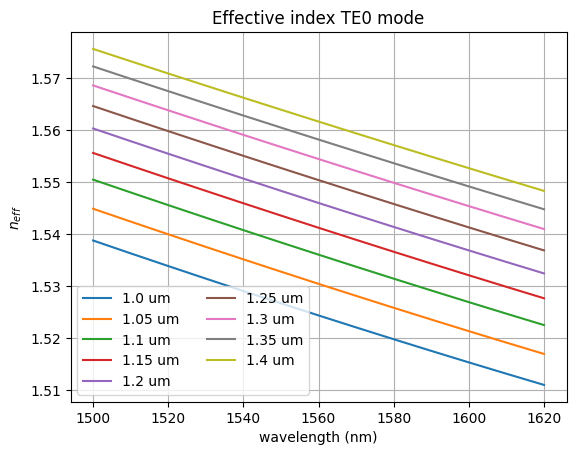

In [4]:
# Extract Effective Indices from Modesolver results
dneff = []
n_eff = []

file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/1.0um/modesolver_results_1.0um.txt"
wavelength_0, neff_0 = open_file_modesolver(file_path)

for w in width:
    file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/{w}um/modesolver_results_{w}um.txt"
    wavelength, neff = open_file_modesolver(file_path)

    dneff.append(np.mean(neff - neff_0))
    n_eff.append(neff)
    plt.plot(wavelength, neff, label=f'{w} um')

plt.title('Effective index TE0 mode')
plt.xlabel('wavelength (nm)')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend(ncols=2)
plt.show()

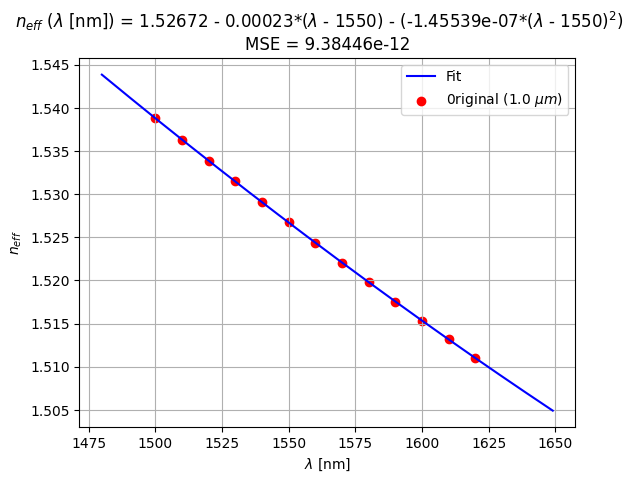

In [5]:
p0 = [1.54, 0, 0]
limits = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
popt, pcov = curve_fit(neff_wl, wavelength, n_eff[0], bounds = limits, p0=p0, maxfev = int(1e5))

neff_test = neff_wl(wavelength, *popt)
mse = np.mean((n_eff[0] - neff_test)**2)

wavelength_test = np.arange(1480, 1650, 1)
neff_test2 = neff_wl(wavelength_test, *popt)

plt.plot(wavelength_test, neff_test2, label = 'Fit', color ='b')
plt.scatter(wavelength, n_eff[0], label = r'0riginal (1.0 $\mu m$)', color ='r')
plt.suptitle(fr'$n_{{eff}}$ ($\lambda$ [nm]) = {popt[0]:.5f} - {popt[1]:.5f}*($\lambda$ - 1550) - ({popt[2]:.5e}*($\lambda$ - 1550)$^2$)')
plt.title(f'MSE = {mse:.5e}')
plt.xlabel(r'$\lambda$ [nm]')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend()
plt.show()

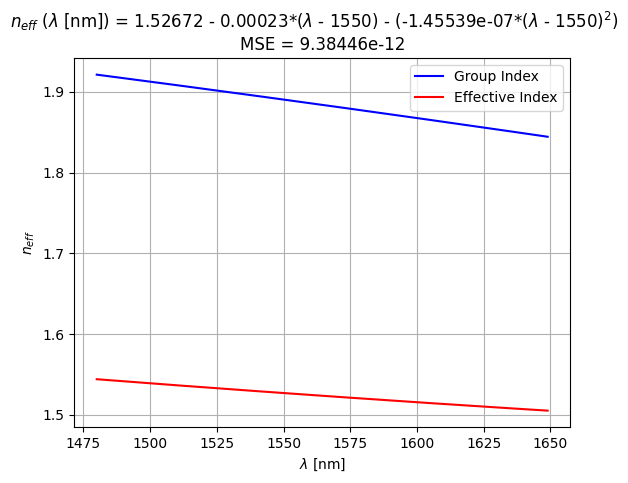

In [6]:
ng_test = neff_wl(wavelength_test, *popt) + wavelength_test*(popt[1] + 2*popt[2]*(wavelength_test - 1550))

plt.plot(wavelength_test, ng_test, label = 'Group Index', color ='b')
plt.plot(wavelength_test, neff_test2, label = 'Effective Index', color ='r')
plt.suptitle(fr'$n_{{eff}}$ ($\lambda$ [nm]) = {popt[0]:.5f} - {popt[1]:.5f}*($\lambda$ - 1550) - ({popt[2]:.5e}*($\lambda$ - 1550)$^2$)')
plt.title(f'MSE = {mse:.5e}')
plt.xlabel(r'$\lambda$ [nm]')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend()
plt.show()

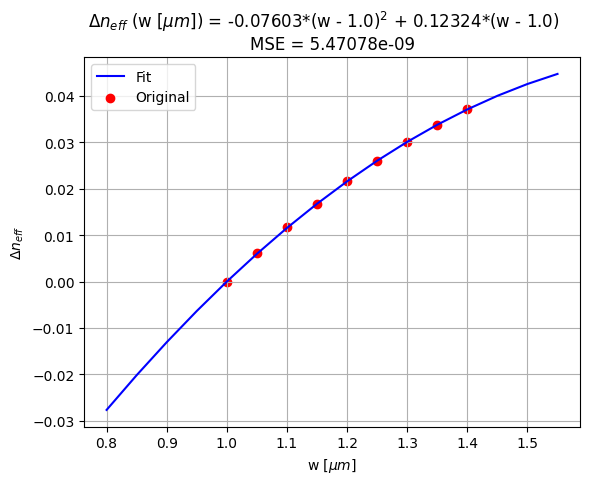

In [7]:
p0 = [0, 0]
limits = ([-np.inf, -np.inf], [np.inf, np.inf])
popt, pcov = curve_fit(dneff_w, width, dneff, bounds = limits, p0=p0, maxfev = int(1e5))

dneff_test = dneff_w(width, *popt)
mse = np.mean((dneff - dneff_test)**2)

width_test = np.arange(0.8, 1.6, 0.05)
dneff_test2 = dneff_w(width_test, *popt)

plt.plot(width_test, dneff_test2, label = 'Fit', color ='b')
plt.scatter(width, dneff, label = 'Original', color ='r')
plt.suptitle(fr'$\Delta n_{{eff}}$ (w $[\mu m]$) = {popt[0]:.5f}*(w - {width_0})$^2$ + {popt[1]:.5f}*(w - {width_0})')
plt.title(f'MSE = {mse:.5e}')
plt.xlabel(r'w $[\mu m]$')
plt.ylabel(r'$\Delta n_{eff}$')
plt.grid()
plt.legend()
plt.show()

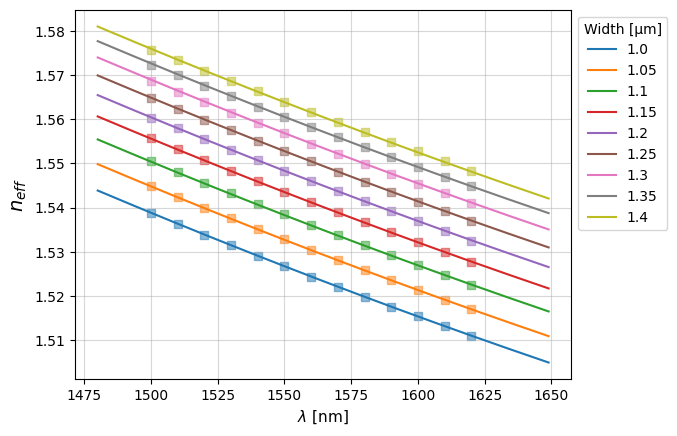

In [8]:
# Create and effective index model for the waveguides as a funcion of wavelength and width
dneff_train = dneff
neff_train = n_eff[0]
wavelength_train = wavelength
width_train = width

wavelength_test = np.arange(1480, 1650, 1)

for i, w in enumerate(width):
    width_test = w
    neff_valid = n_eff[i]

    mse, neff_test, popt_w, popt_wl = neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid)

    fit, = plt.plot(wavelength_test, neff_test, label = f'{width_test}')
    plt.scatter(wavelength, neff_valid, color = fit.get_color(), alpha=0.5, marker='s')
    
#plt.title(fr'Effective refractive index fit for {material}')
plt.xlabel(r'$\lambda$ [nm]', fontsize=11)
plt.ylabel(r'$n_{eff}$', fontsize=14)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize = 10, title='Width [μm]', bbox_to_anchor=(1, 1), loc='upper left')
#plt.savefig("SiO2_index.png", dpi=300, bbox_inches="tight")
plt.show()

# U1

## Period Calculation

U1 parameters 

λ   = [1520 1530 1540 1550 1560 1570 1580 1590] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150. 175. 200.] (nm)
Λ   = [494.5100947  497.64142118 500.82363834 504.05772417 507.34468885
 510.68557587 514.08146312 517.53346404] (nm)


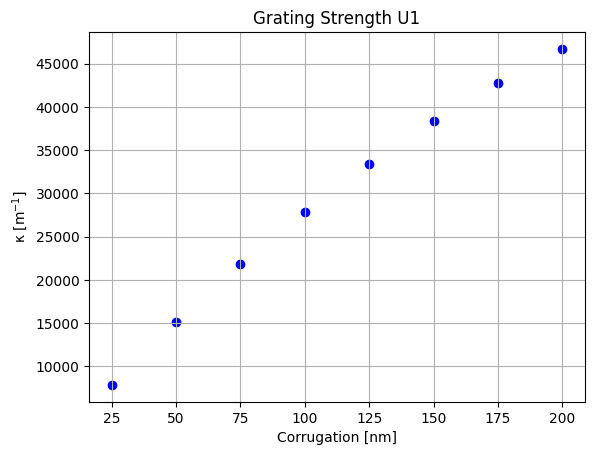

In [30]:
# Obtain the grating period for each U1 Bragg grating
period_array_u1 = []
n1_array = []
n2_array = []
n_avg_u1 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u1:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u1.append(float(n_avg))
    period_array_u1.append(float(period*1e-3))
    i+=1

print('U1 parameters \n')
print(f'λ   = {wl_u1} (nm)')
print(f'ΔW  = {(width[1:] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u1)*1e3} (nm)')

# Grating Strength Estimation
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u1 = 2*delta_n/((np.array(n1_array)  + np.array(n2_array))*np.array(period_array_u1)*1e-6)
plt.scatter((width[1:] - width_0)/2*1e3, kappa_u1, color='b')

plt.title('Grating Strength U1')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

## Corrugation Profile

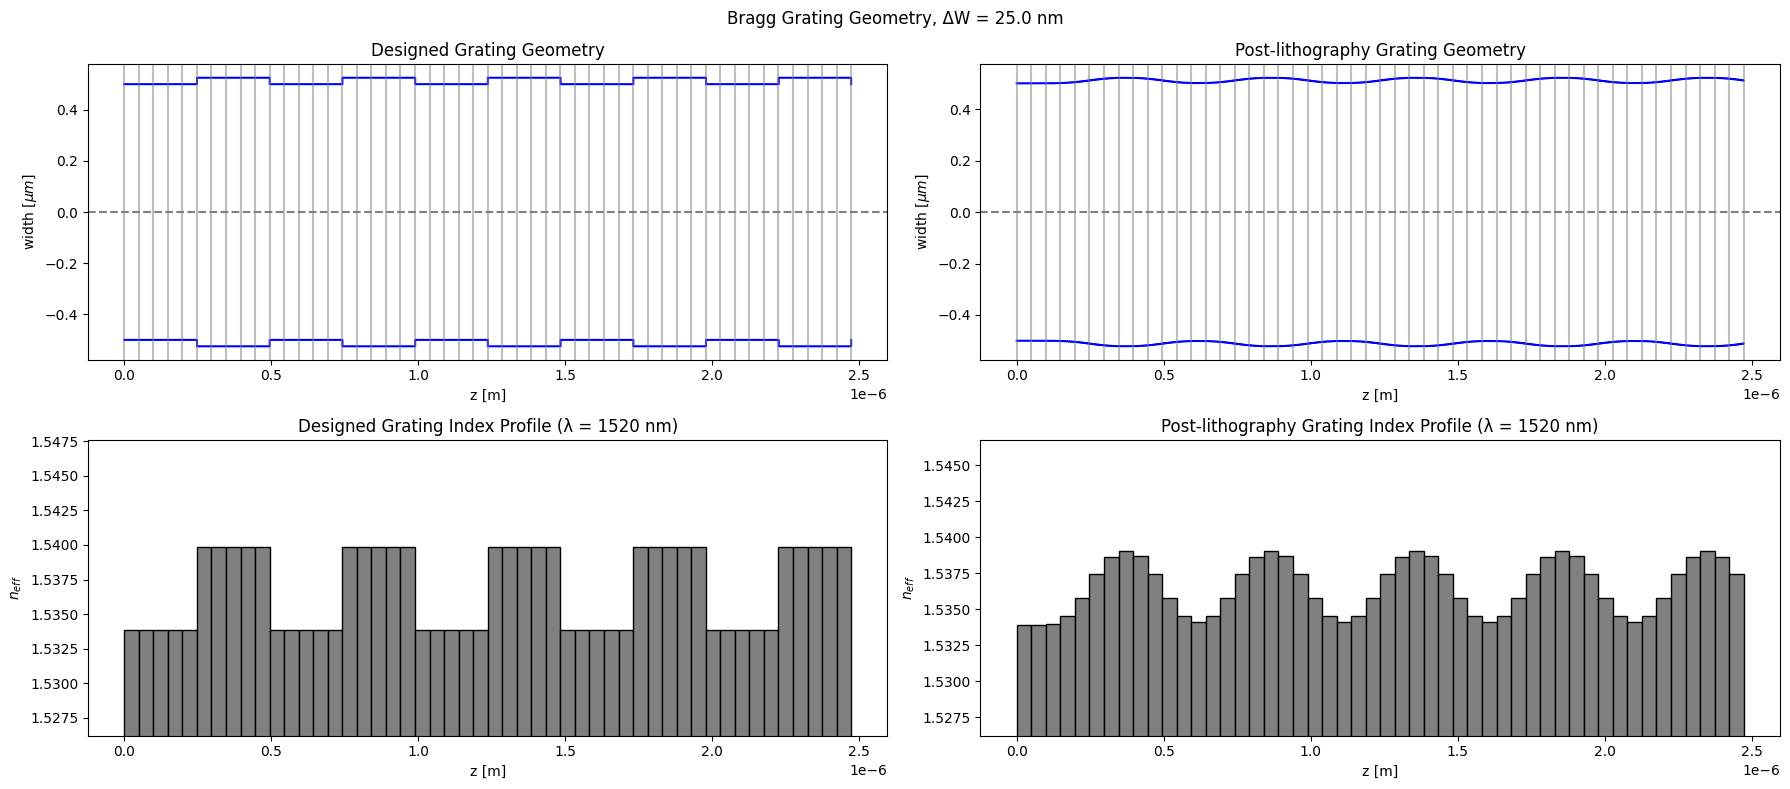

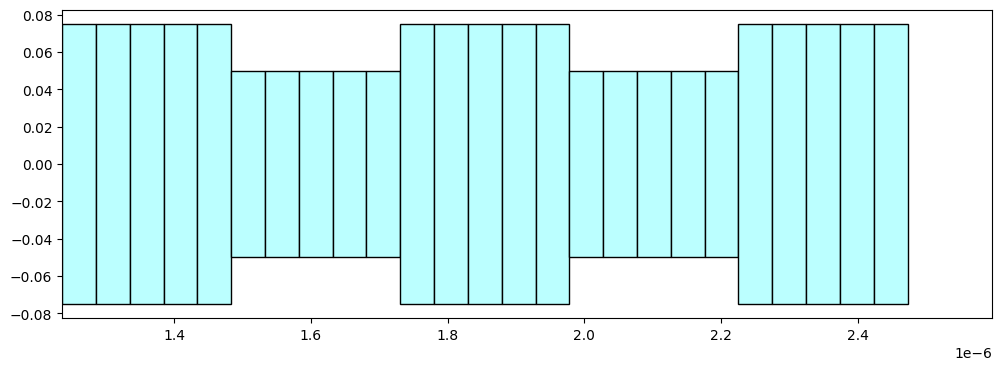

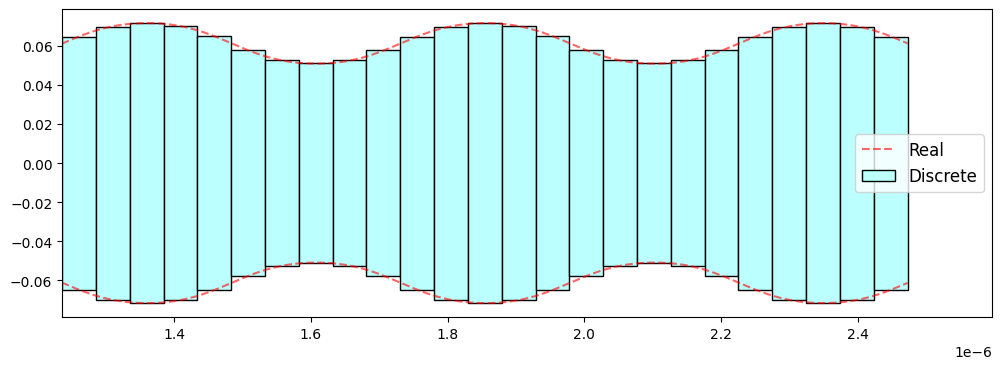

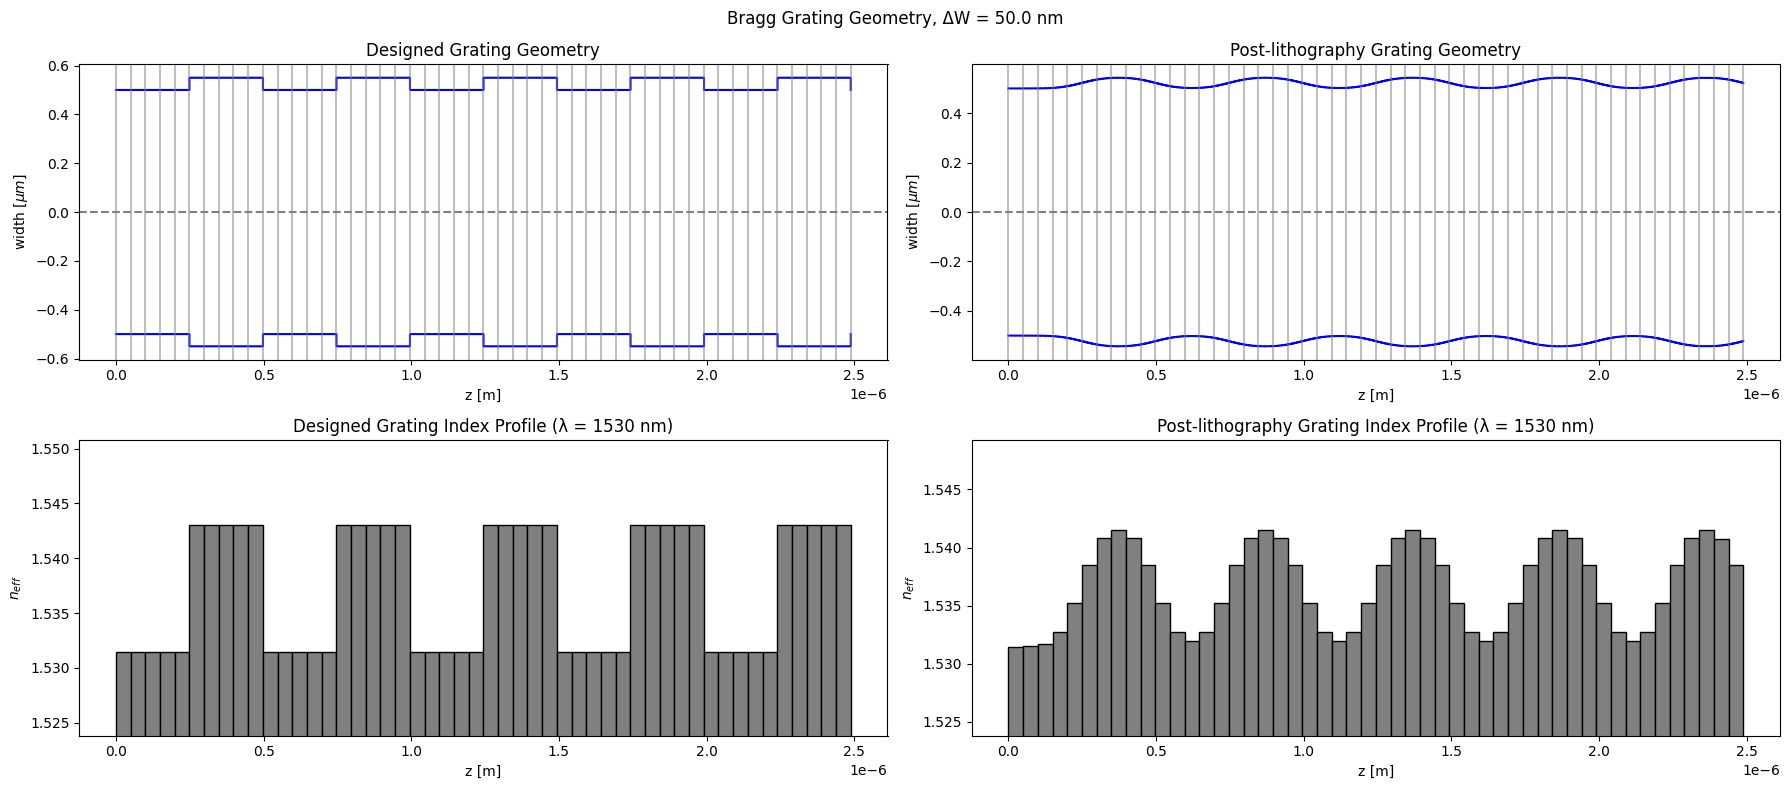

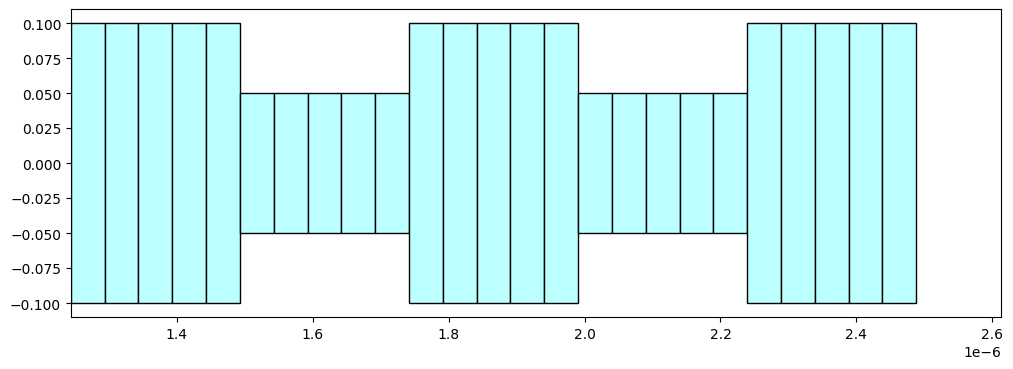

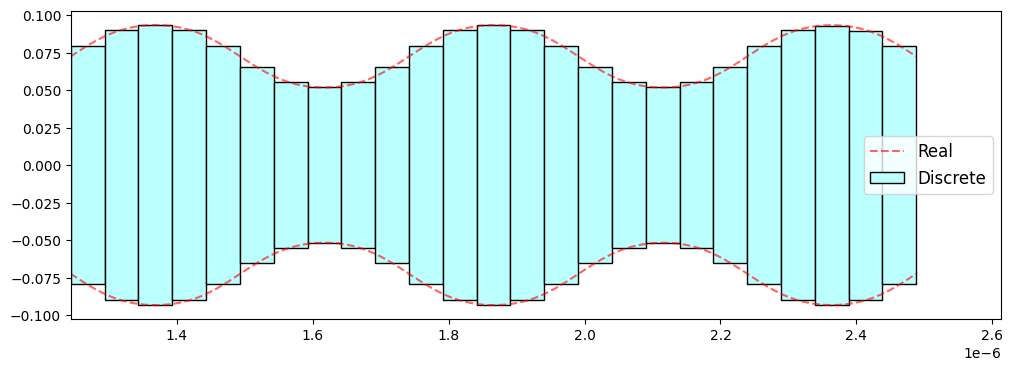

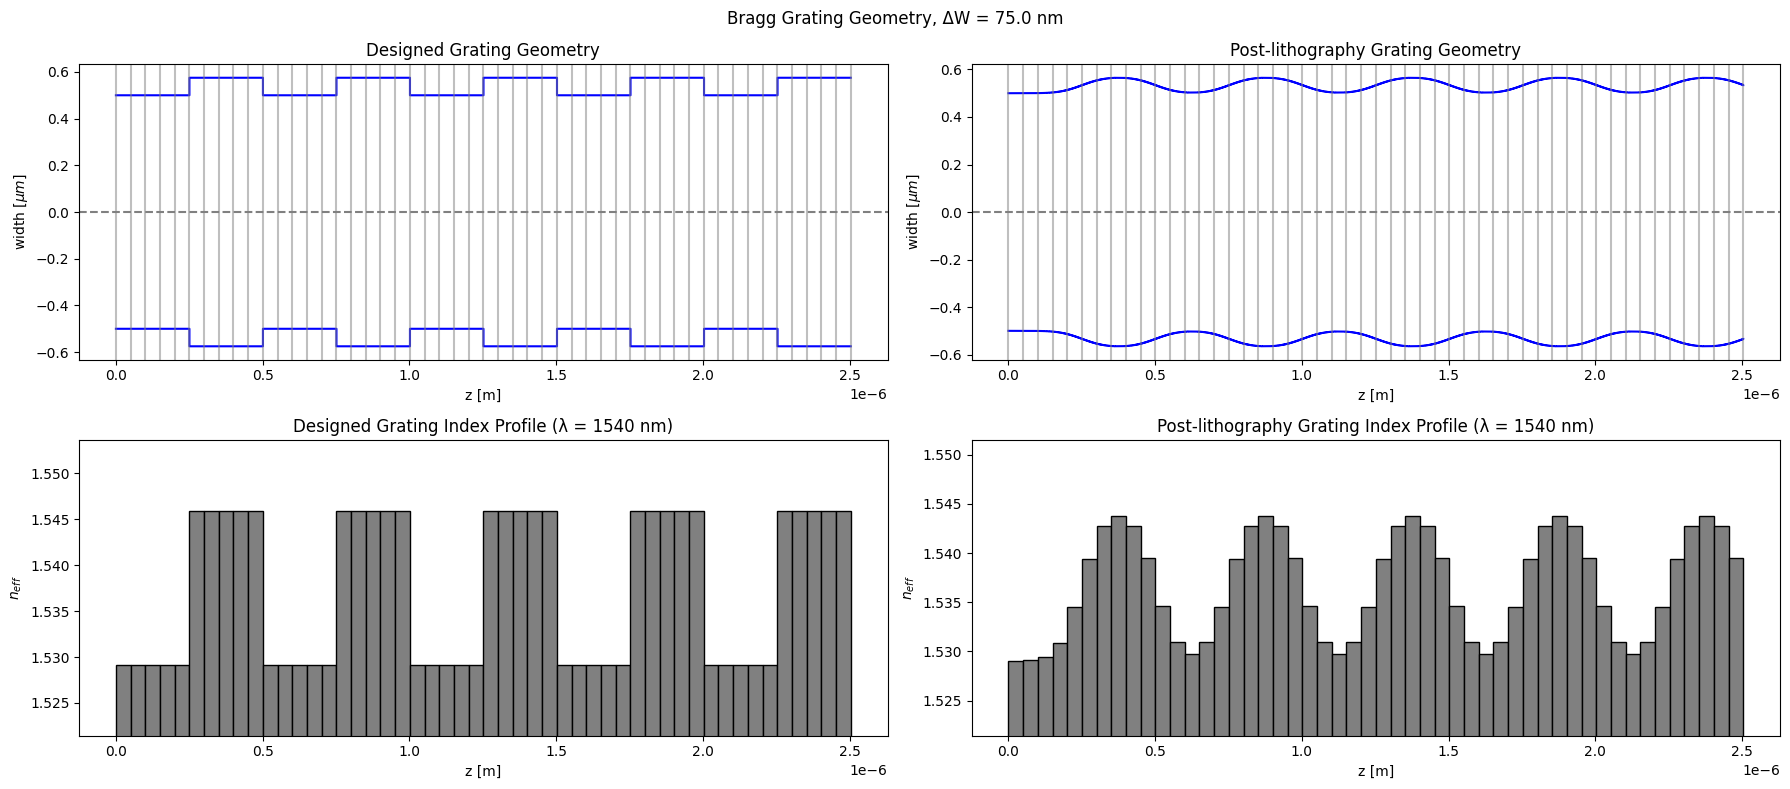

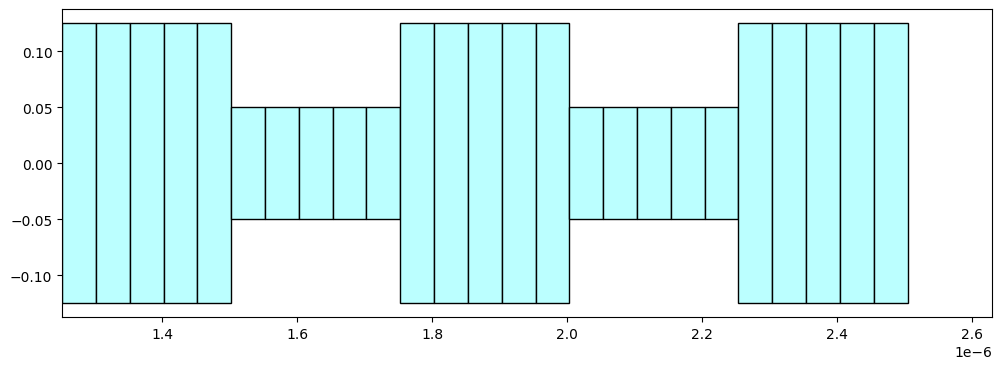

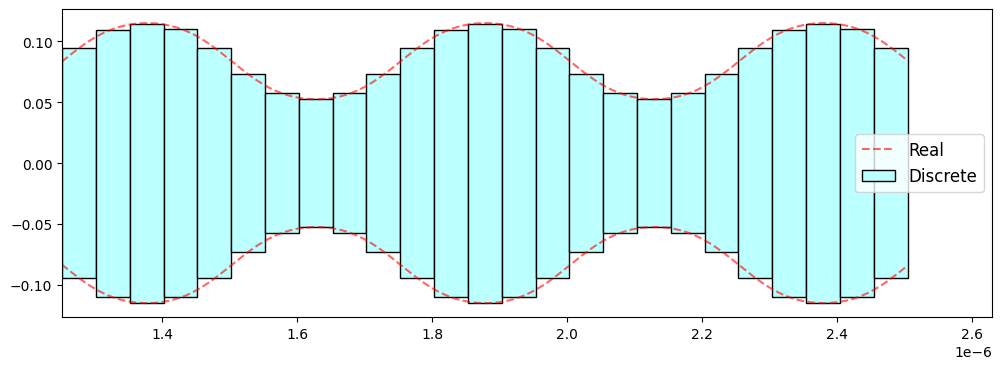

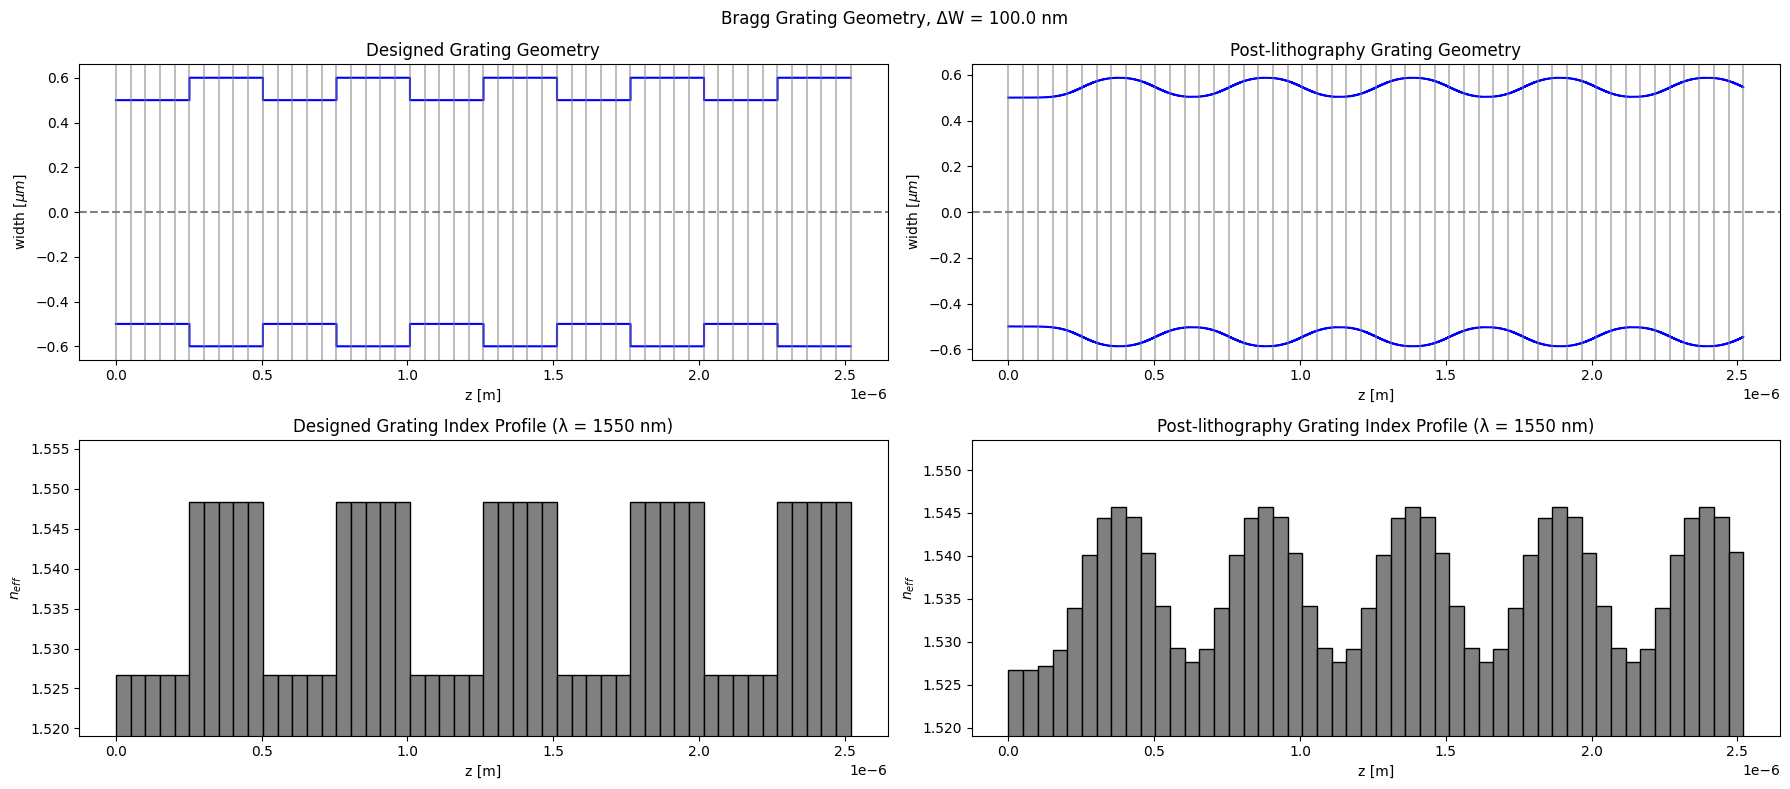

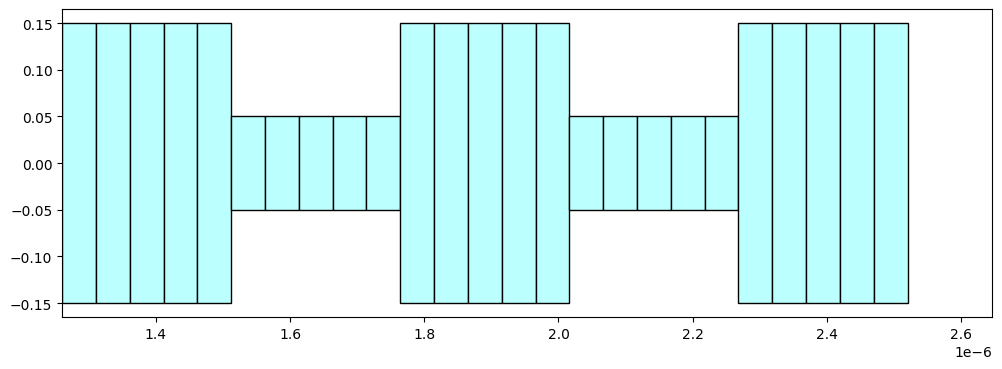

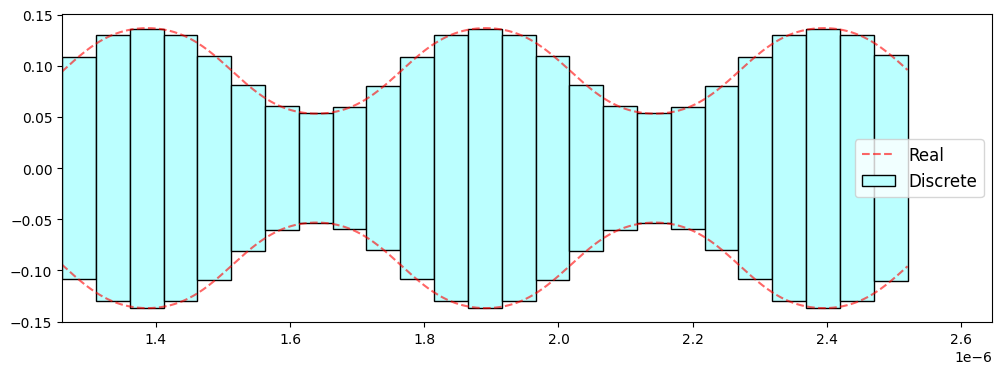

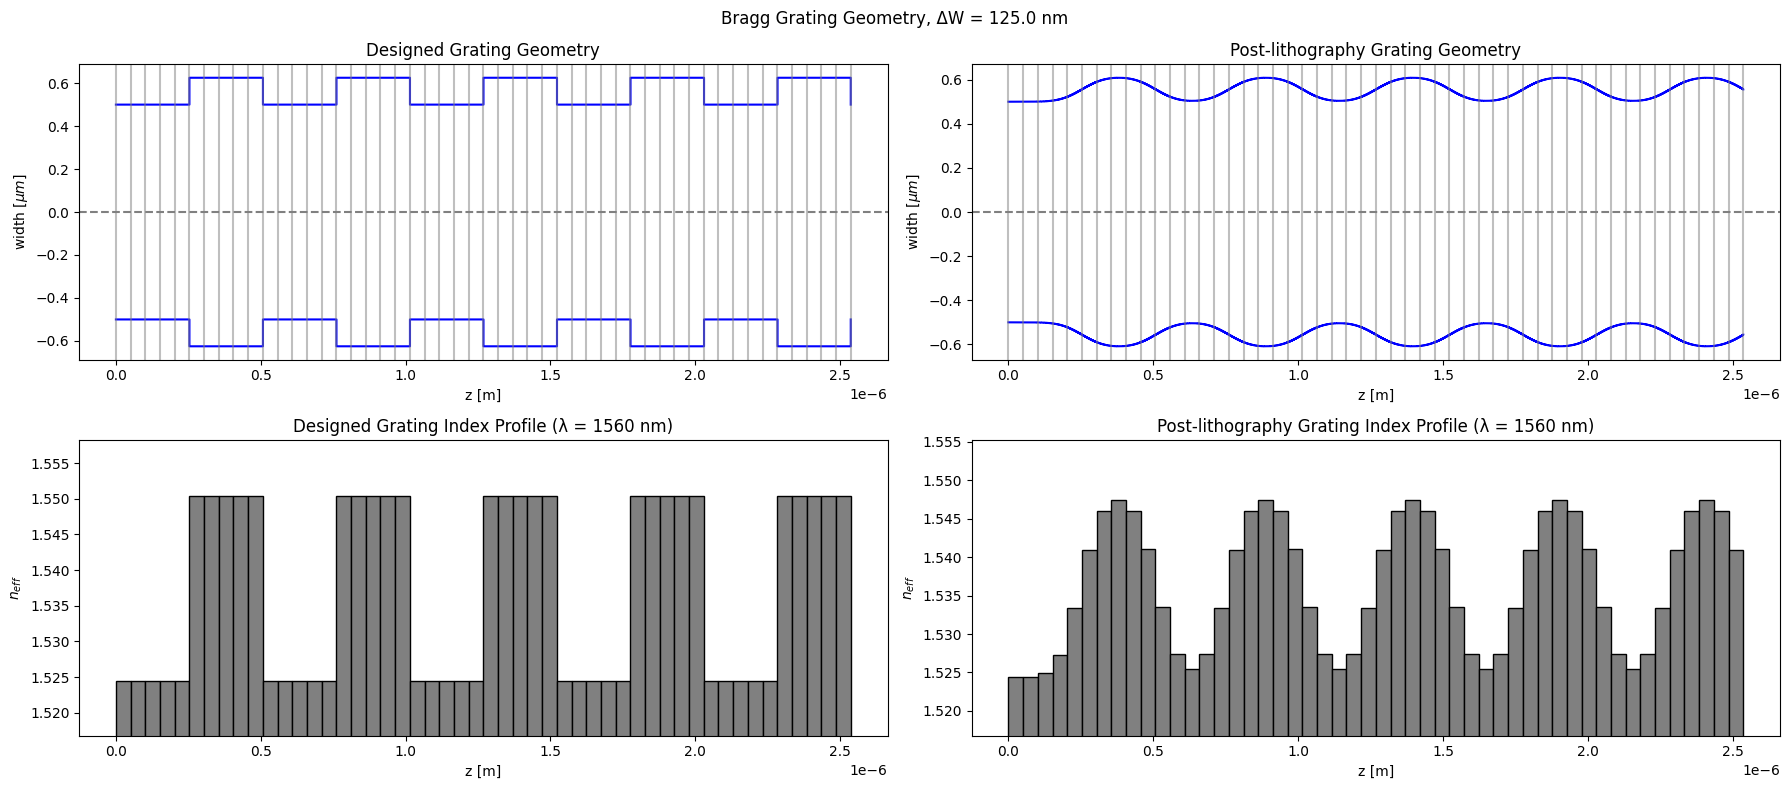

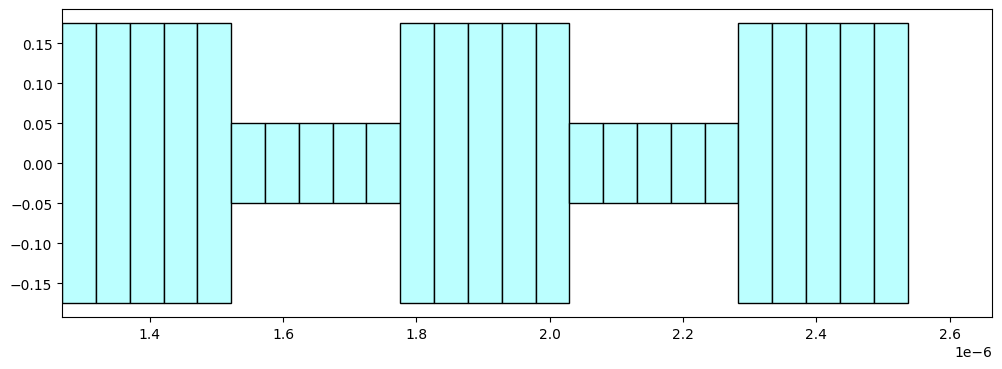

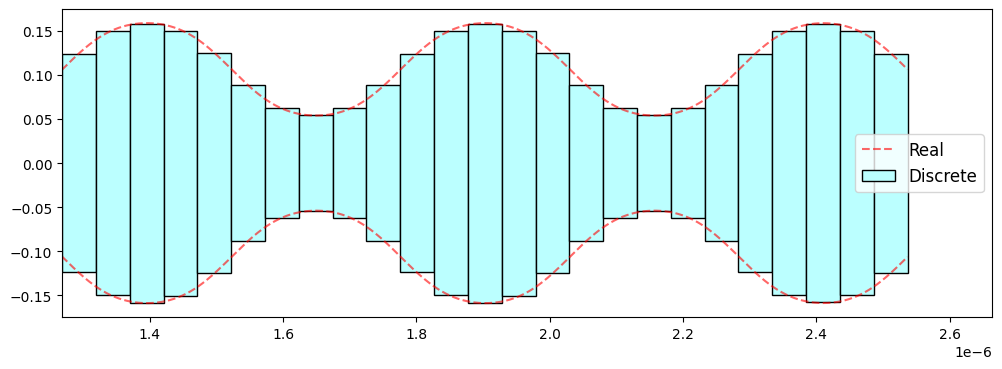

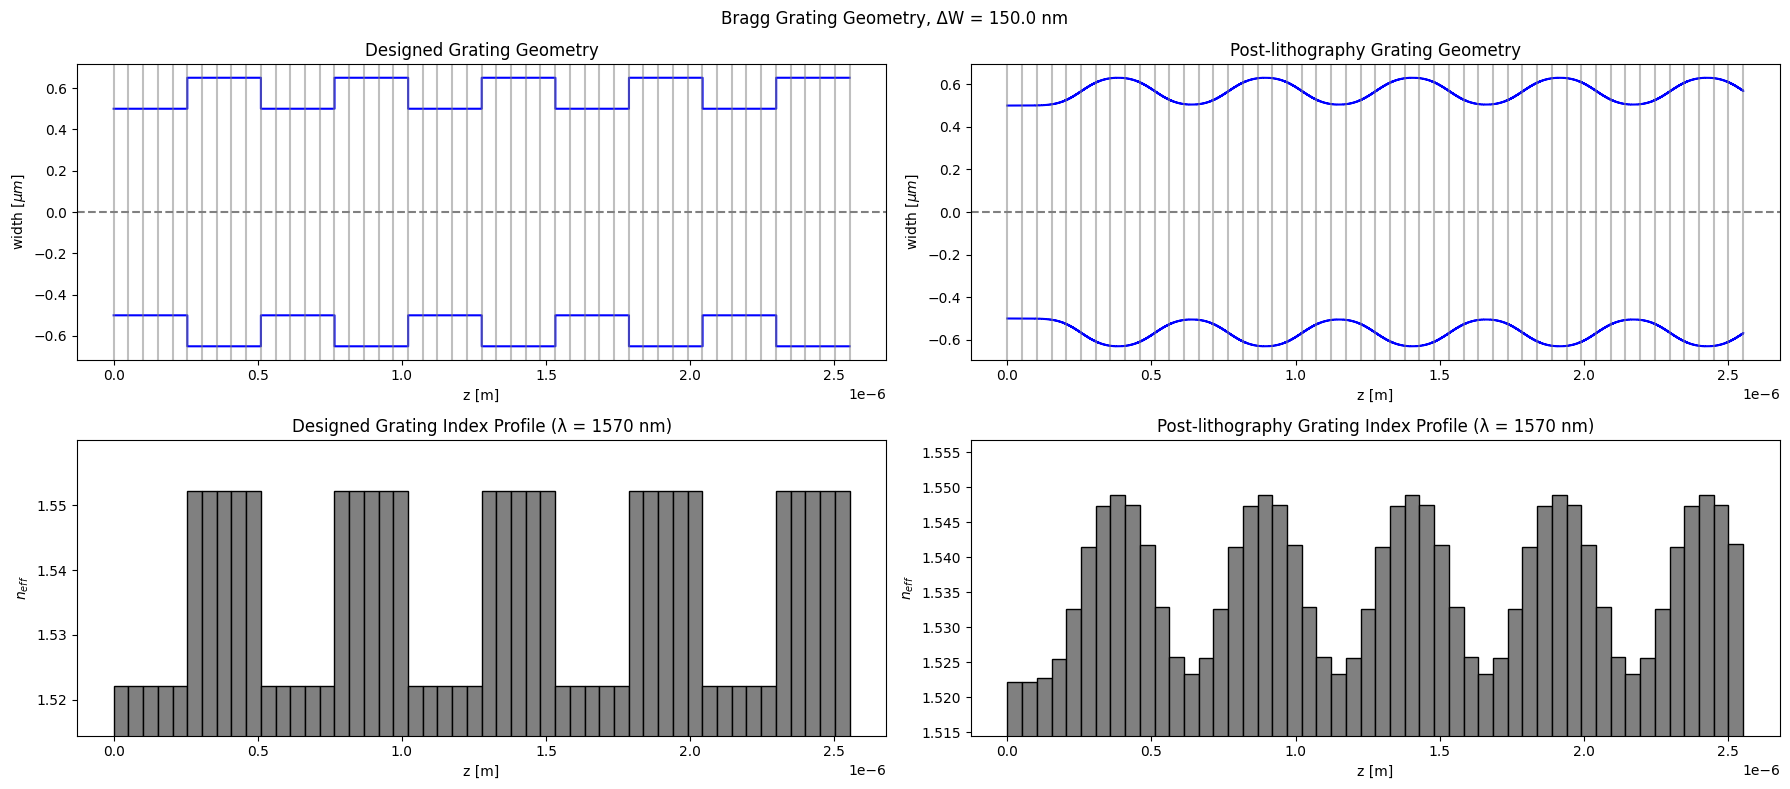

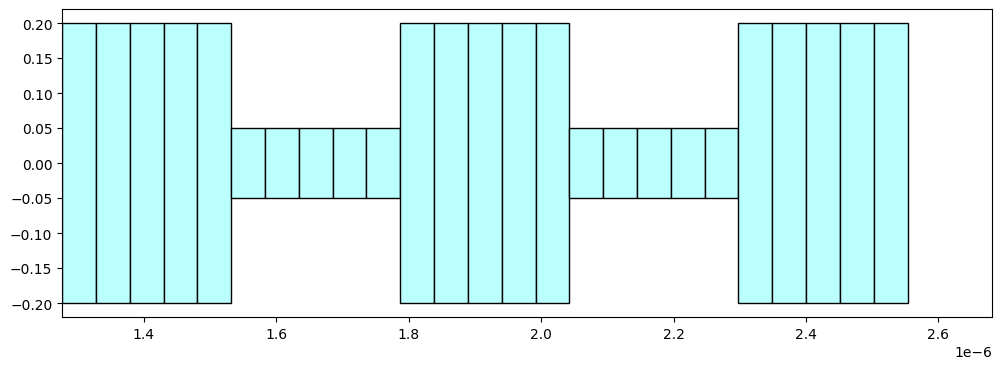

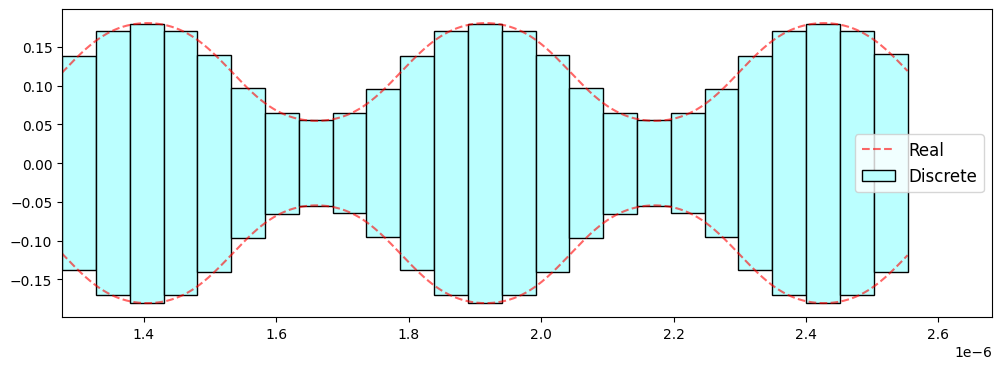

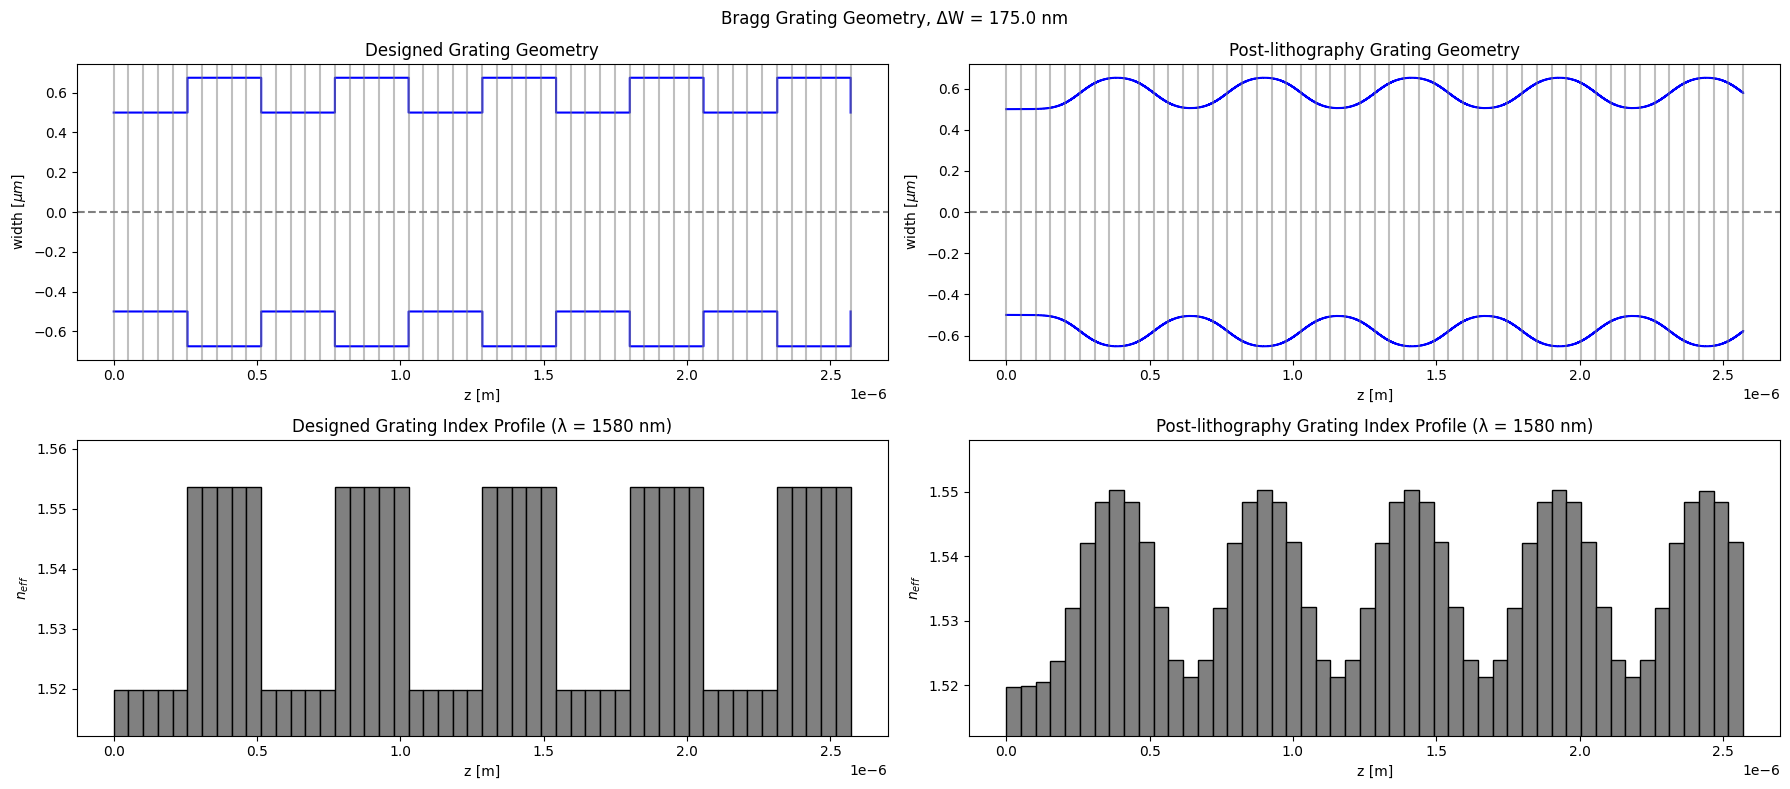

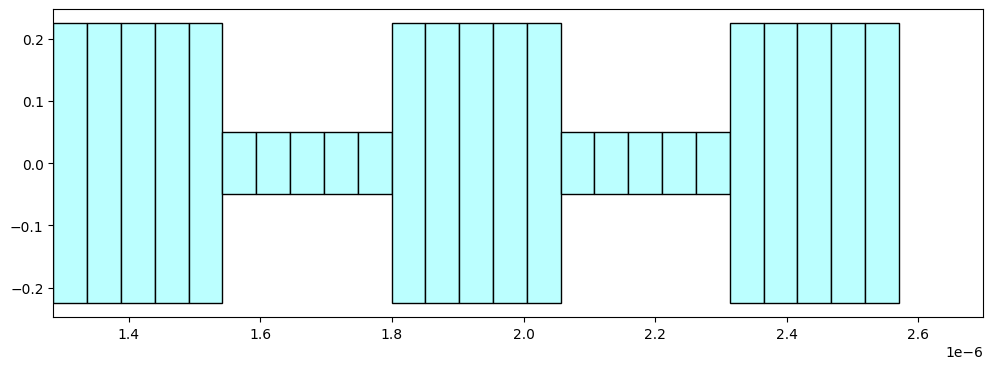

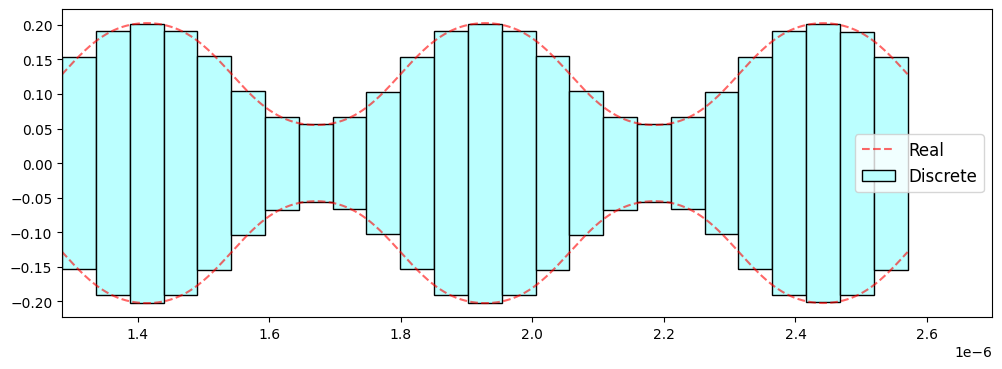

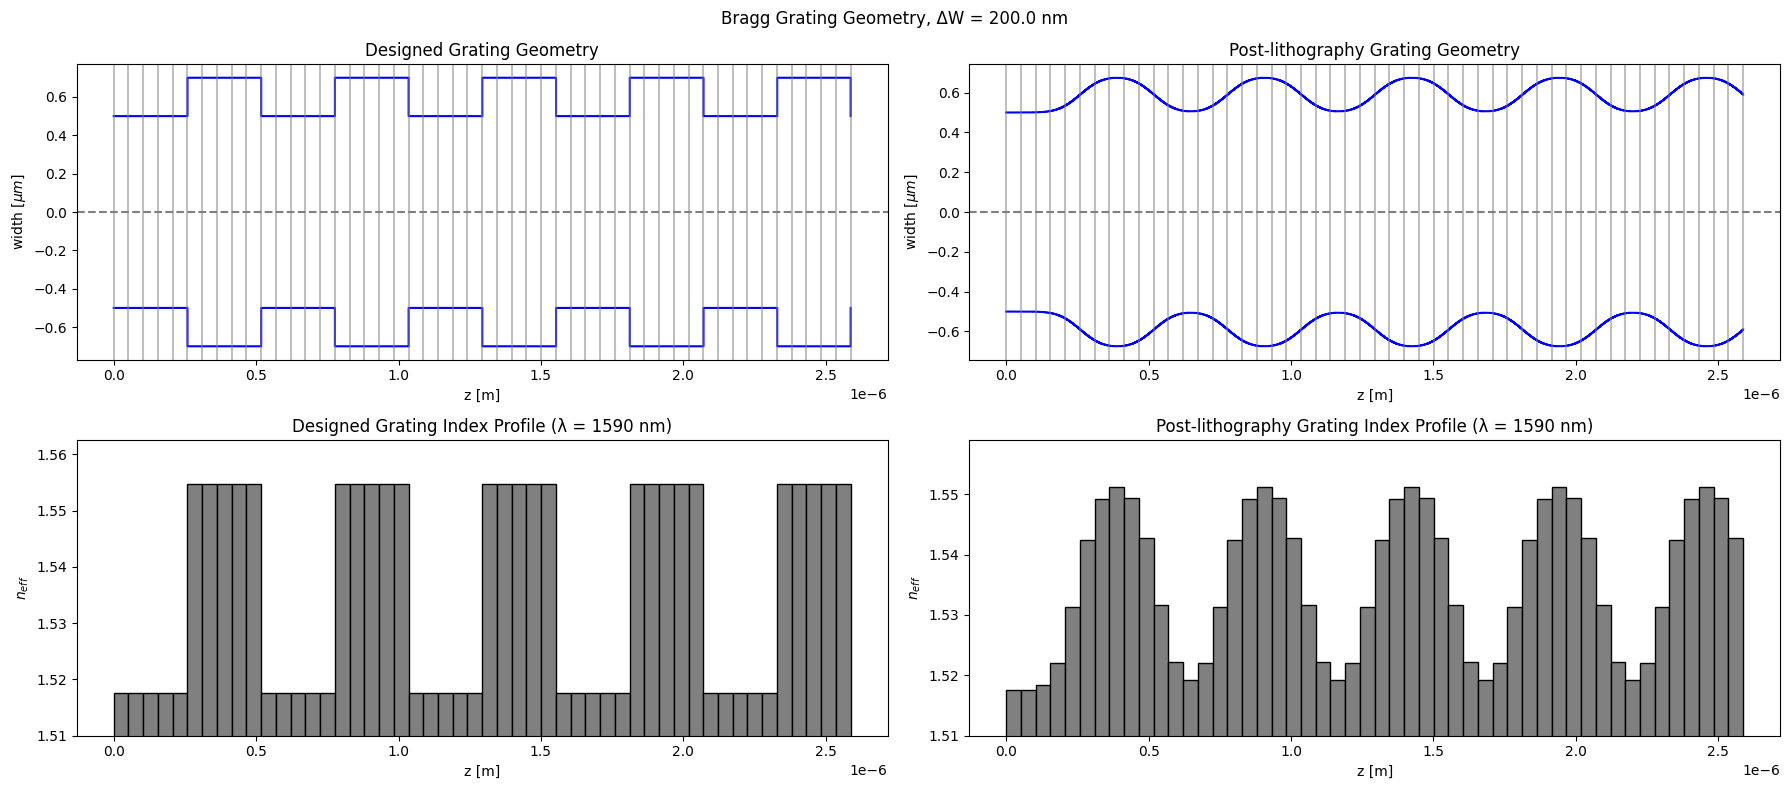

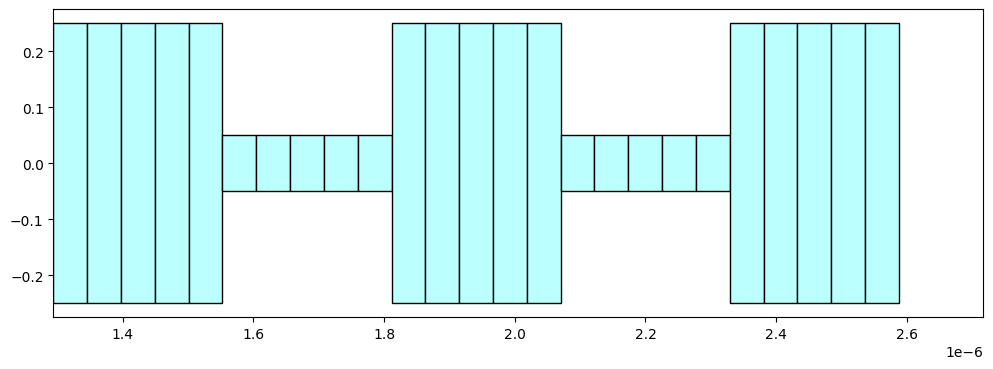

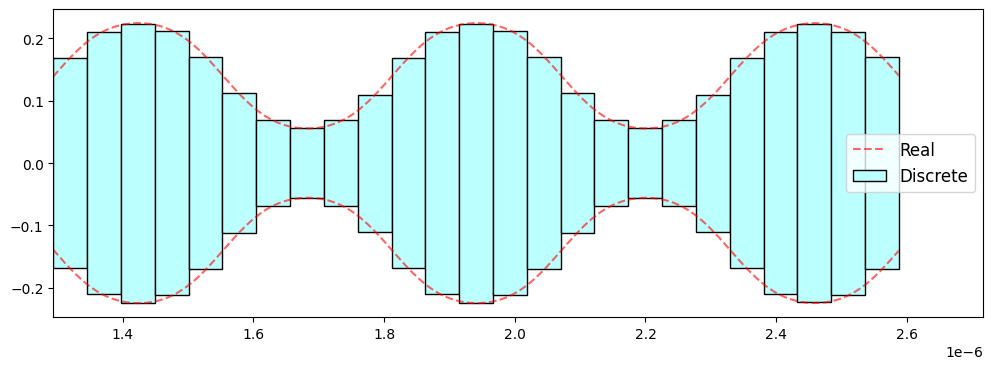

In [31]:
# Corrugation profile for each Bragg grating
dwidth_1 = 0
N = 5
M = 5*(2*N)

for i, period in enumerate(period_array_u1):
    z_real, dw_real_p, dw_real_n = uniform_grating(period*1e-6, dwidth[i+1], N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M)

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M)

    w_mean = dw_mean_p - dw_mean_n + width_0
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0
    
    n_mean = neff_wl(wl_u1[i], *popt_wl) + dneff_w(w_mean, *popt_w)
    n_mean_fab = neff_wl(wl_u1[i], *popt_wl) + dneff_w(w_mean_fab, *popt_w)

    fig, axs = plt.subplots(2, 2, figsize=(18, 8))
    axs[0, 0].step(z_real, dw_real_p + width_0/2, where='post', label='Real', color='blue')
    axs[0, 0].step(z_real, dw_real_n - width_0/2, where='post', color='blue')

    #axs[0, 0].step(z_edges[:-1], dw_mean_p + width_0/2, where='post', label='Discrete', color='red')
    #axs[0, 0].step(z_edges[:-1], dw_mean_n - width_0/2, where='post', color='red')
    axs[0, 0].axhline(0, color='grey', linestyle='--')

    axs[0, 1].step(z_real, dw_fab_p + width_0/2, where='post', label='Pred.', color='blue')
    axs[0, 1].step(z_real, dw_fab_n - width_0/2, where='post', color='blue')

    #axs[0, 1].step(z_edges_fab[:-1], dw_mean_fab_p + width_0/2, where='post', label='Discrete pred.', color='red')
    #axs[0, 1].step(z_edges_fab[:-1], dw_mean_fab_n - width_0/2, where='post', color='red')
    axs[0, 1].axhline(0, color='grey', linestyle='--')

    axs[1, 0].bar(z_edges[:-1] + (z_edges[1] - z_edges[0])/2, n_mean, width=(z_edges[1] - z_edges[0]), color='grey', edgecolor='black')
    axs[1, 1].bar(z_edges_fab[:-1] + (z_edges_fab[1] - z_edges_fab[0])/2, n_mean_fab, width=(z_edges_fab[1] - z_edges_fab[0]), color='grey', edgecolor='black')

    if M <= 100:
        for z_cut in z_edges:
            axs[0, 0].axvline(z_cut, color='grey', alpha=0.5)

        for z_cut in z_edges_fab:
            axs[0, 1].axvline(z_cut, color='grey', alpha=0.5)

    axs[0, 0].set_title('Designed Grating Geometry')
    axs[0, 0].set_ylabel(r'width $[\mu m]$')
    axs[0, 0].set_xlabel('z [m]')
    #axs[0, 0].legend()

    axs[0, 1].set_title('Post-lithography Grating Geometry')
    axs[0, 1].set_xlabel('z [m]')
    axs[0, 1].set_ylabel(r'width $[\mu m]$')
    #axs[0, 1].legend()

    axs[1, 0].set_title(f'Designed Grating Index Profile (λ = {wl_u1[i]} nm)')
    axs[1, 0].set_xlabel('z [m]')
    axs[1, 0].set_ylabel(r'$n_{eff}$')
    axs[1, 0].set_ylim(min(n_mean)*0.995, max(n_mean)*1.005)

    axs[1, 1].set_title(f'Post-lithography Grating Index Profile (λ = {wl_u1[i]} nm)')
    axs[1, 1].set_xlabel('z [m]')
    axs[1, 1].set_ylabel(r'$n_{eff}$')
    axs[1, 1].set_ylim(min(n_mean_fab)*0.995, max(n_mean_fab)*1.005)

    plt.suptitle(fr'Bragg Grating Geometry, ΔW = {dwidth[i+1]*1e3:.1f} nm')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4))

    y_top = dw_mean_p + width_0/20
    y_bottom = dw_mean_n - width_0/20
    
    for j in range(len(z_edges_fab) - 1):
        x_left = z_edges[j]
        w = z_edges[j+1] - z_edges[j]
        y_min = y_bottom[j]
        height = y_top[j] - y_min
        
        rect = patches.Rectangle(
            (x_left, y_min), w, height,
            facecolor='#bbffff',
            edgecolor='black', # o el color de borde que prefieras
            linewidth=1.0,
            # Asignamos label solo al primero para no duplicar en la leyenda
            label='Discrete pred.' if j == 0 else ""
        )
        ax.add_patch(rect)

    # Asegurar que los límites de la gráfica se ajusten bien
    ax.autoscale()
    plt.xlim(max(z_real)/2)
    #plt.savefig("rect_disctretization_n2", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4))

    # --- Tu gráfica previa ---
    ax.plot(z_real, dw_fab_p + width_0/20, label='Real', color='red', linestyle='--', alpha=0.6)
    ax.plot(z_real, dw_fab_n - width_0/20, color='red', linestyle='--', alpha=0.6)

    # --- Dibujar cada bloque independiente ---
    y_top = dw_mean_fab_p + width_0/20
    y_bottom = dw_mean_fab_n - width_0/20

    
    for k in range(len(z_edges_fab) - 1):
        x_left = z_edges_fab[k]
        w = z_edges_fab[k+1] - z_edges_fab[k]
        y_min = y_bottom[k]
        height = y_top[k] - y_min
        
        rect = patches.Rectangle(
            (x_left, y_min), w, height,
            facecolor='#bbffff',
            edgecolor='black', # o el color de borde que prefieras
            linewidth=1.0,
            # Asignamos label solo al primero para no duplicar en la leyenda
            label='Discrete' if k == 0 else ""
        )
        ax.add_patch(rect)

    # Asegurar que los límites de la gráfica se ajusten bien
    ax.autoscale()
    plt.legend(fontsize=12)
    plt.xlim(max(z_real)/2)
    #plt.savefig("cosine_disctretization_n2", dpi=300, bbox_inches="tight")
    plt.show()

## TMM Simulation

### Design

In [11]:
# TMM Simulation
n_u1 = 1
M_u1 = n_u1*(2*N_u1)

T_u1 = []
phi_r_u1 = []
phi_t_u1 = []
tau_r_u1 = []
tau_t_u1 = []

for i in range(len(period_array_u1)):
    t_inicio = time.perf_counter()
    L = N_u1*period_array_u1[i]*1e-6
    dz = L/M_u1

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u1[i]*1e-6, dwidth[i+1], N_u1, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.25)*1e-9
    M_wl = Bragg_grating(wavelength_test, w_mean, dz, M_u1, popt_wl, popt_w)
    
    T_buff = []
    phi_r_buff = []
    phi_t_buff = []
    
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        phi_r_buff.append(np.angle(1/M_wl[j][0, 0]))
        phi_t_buff.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))

    aux = wavelength_test**2/(2*np.pi*3e8)
    tau_r_buff = aux*np.gradient(np.unwrap(np.array(phi_r_buff)), wavelength_test)
    tau_t_buff = aux*np.gradient(np.unwrap(np.array(phi_t_buff)), wavelength_test)

    T_u1.append(T_buff)
    phi_r_u1.append(np.unwrap(np.array(phi_r_buff)))
    phi_t_u1.append(np.unwrap(np.array(phi_t_buff)))
    tau_r_u1.append(tau_r_buff)
    tau_t_u1.append(tau_t_buff)

    t_final = time.perf_counter()
    print(f'Time for TMM simulation {i}: {t_final - t_inicio:.2f} s')

Time for TMM simulation 0: 2.53 s
Time for TMM simulation 1: 2.53 s
Time for TMM simulation 2: 2.50 s
Time for TMM simulation 3: 2.57 s
Time for TMM simulation 4: 2.53 s
Time for TMM simulation 5: 2.49 s
Time for TMM simulation 6: 2.48 s
Time for TMM simulation 7: 2.46 s


In [49]:
# Definimos los valores de N_u1 a probar
N_u1_array = [100, 200, 300, 500, 600, 700, 800, 900, 1000, 1500, 2000, 3000, 4000, 5000]  # Modifica este rango según tus necesidades

# Fijamos i = 0 y el valor de n_u1
i = 0
n_u1 = 1  # Fijamos n_u1 a un valor constante
wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.25)*1e-9

T_N_u1 = []       # Almacenará T para cada valor de N_u1
tiempos = []      # Almacenará el tiempo que tarda cada N_u1

for N_u1 in N_u1_array:
    t_inicio = time.perf_counter()  # Marca el inicio
    
    # M_u1 depende de N_u1
    M_u1_fab = int(n_u1 * (2 * N_u1))
    
    L = N_u1 * period_array_u1[i] * 1e-6
    dz = L / M_u1_fab

    # Geometría de la red para el N_u1 actual
    z_real, dw_real_p, dw_real_n = uniform_grating(
        period_array_u1[i] * 1e-6, 
        dwidth[i + 1], 
        N_u1, 
        duty=0.5, 
        dL=0
    )
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1_fab)
    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u1_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    # Cálculo de la matriz de transferencia y transmisión
    M_wl = Bragg_grating(wavelength_test, w_mean_fab, dz, M_u1_fab, popt_wl, popt_w)
    
    # Vectorización de la transmisión
    T_buff = [1 / (np.abs(M_wl[j][0, 0])**2) for j in range(len(wavelength_test))]
    
    t_fin = time.perf_counter()  # Marca el final
    duracion = t_fin - t_inicio
    
    T_N_u1.append(T_buff)
    tiempos.append(duracion)
    
    print(f"N_u1 = {N_u1} -> Execution Time: {duracion:.4f} seconds")

N_u1 = 100 -> Execution Time: 0.2334 seconds
N_u1 = 200 -> Execution Time: 0.4654 seconds
N_u1 = 300 -> Execution Time: 0.7999 seconds
N_u1 = 500 -> Execution Time: 1.3900 seconds
N_u1 = 600 -> Execution Time: 1.7796 seconds
N_u1 = 700 -> Execution Time: 2.3654 seconds
N_u1 = 800 -> Execution Time: 2.9332 seconds
N_u1 = 900 -> Execution Time: 2.9222 seconds
N_u1 = 1000 -> Execution Time: 3.2415 seconds
N_u1 = 1500 -> Execution Time: 5.8262 seconds
N_u1 = 2000 -> Execution Time: 9.9732 seconds
N_u1 = 3000 -> Execution Time: 28.9577 seconds
N_u1 = 4000 -> Execution Time: 50.1058 seconds
N_u1 = 5000 -> Execution Time: 67.8528 seconds


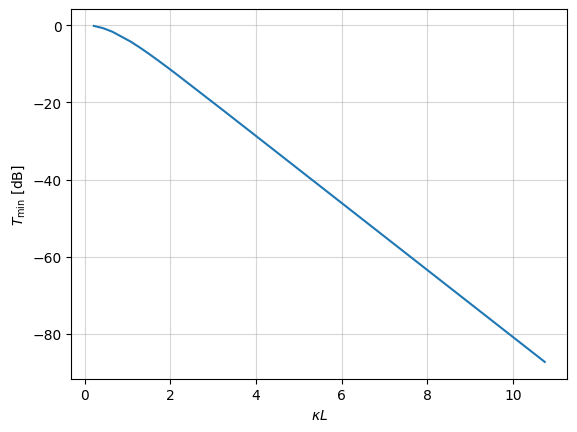

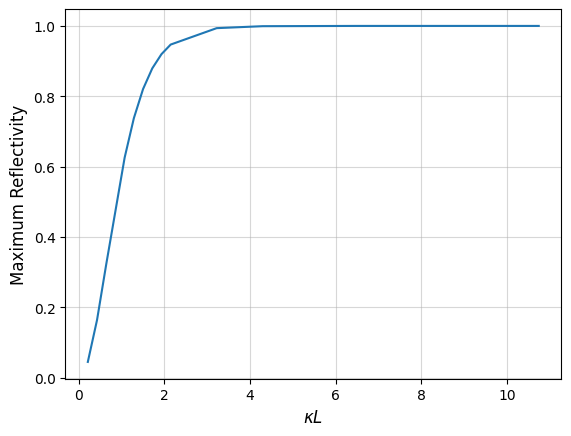

In [50]:
power_min = []
r_max = []
kappaL = []

for i, T in enumerate(T_N_u1):
    power_min.append(10*np.log10(min(T)))
    r_max.append(1-min(T))
    kappaL.append(np.arctanh(np.sqrt(1 - 10**(power_min[i]/10))))

plt.plot(kappaL, power_min)
plt.xlabel(r'$\kappa L$')
plt.ylabel(r'$T_{\mathrm{min}}$ [dB]')
plt.grid(alpha=0.5)
plt.show()

plt.plot(kappaL, r_max)
plt.xlabel(r'$\kappa L$', fontsize=12)
plt.ylabel('Maximum Reflectivity', fontsize=12)
plt.grid(alpha=0.5)
plt.savefig("kL_saturation.png", dpi=300, bbox_inches="tight")
plt.show()

### Convergence

In [ ]:
# Definimos los valores de n_u1 a probar
n_u1_array = np.arange(2, 23, 3)  # Modifica estos valores según tus necesidades

# Fijamos i = 0
i = 0
wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.25)*1e-9

T_n_u1 = []       # Almacenará T para cada valor de n_u1
tiempos = []      # Almacenará el tiempo que tarda cada n_u1

for n_u1 in n_u1_array:
    t_inicio = time.perf_counter()  # Marca el inicio
    
    # M_u1 debe ser entero para representar el número de divisiones/puntos
    M_u1_fab = int(n_u1 * (2 * N_u1))
    
    L = N_u1 * period_array_u1[i] * 1e-6
    dz = L / M_u1_fab

    # Geometría de la red para i = 0
    z_real, dw_real_p, dw_real_n = uniform_grating(
        period_array_u1[i] * 1e-6, 
        dwidth[i + 1], 
        N_u1, 
        duty=0.5, 
        dL=0
    )
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1_fab)
    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u1_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    # Cálculo de la matriz de transferencia y transmisión
    M_wl = Bragg_grating(wavelength_test, w_mean_fab, dz, M_u1_fab, popt_wl, popt_w)
    
    # Vectorizado de la transmisión
    T_buff = []
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
    
    t_fin = time.perf_counter()  # Marca el final
    duracion = t_fin - t_inicio
    
    T_n_u1.append(T_buff)
    tiempos.append(duracion)
    
    print(f"n = {n_u1} -> Execution Time: {duracion:.4f} seconds")

n = 2 -> Execution Time: 6.1780 seconds
n = 5 -> Execution Time: 14.8071 seconds
n = 8 -> Execution Time: 22.9156 seconds
n = 11 -> Execution Time: 32.0381 seconds
n = 14 -> Execution Time: 40.5831 seconds
n = 17 -> Execution Time: 48.6829 seconds
n = 20 -> Execution Time: 56.9866 seconds


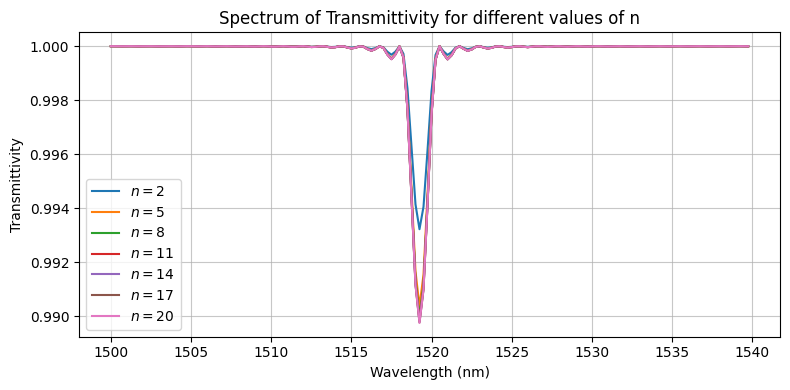

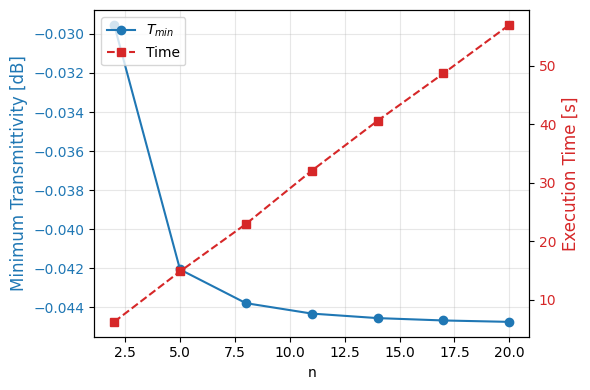

In [20]:
# Plot del espectro T para el n_u1 actual (convertimos nm para el eje X)
fig = plt.figure(figsize=(8, 4))
for k in range(len(n_u1_array)):
    plt.plot(wavelength_test * 1e9, T_n_u1[k], label=f'$n = {n_u1_array[k]}$')

# Formato de la gráfica
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmittivity')
plt.title('Spectrum of Transmittivity for different values of n')
plt.grid(True, alpha=0.7)
plt.legend()
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# Extraemos la transmisión mínima en dB para cada n
min_T_db = [10 * np.min(np.log10(T)) for T in T_n_u1]

# Crear figura y primer eje (Eje Y izquierdo)
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.set_xlabel('n')
ax1.set_ylabel('Minimum Transmittivity [dB]', color='tab:blue', fontsize=12)
line1 = ax1.plot(n_u1_array, min_T_db, 'o-', color='tab:blue', label=r'$T_{min}$')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.ticklabel_format(useOffset=False, axis='y') # Evita el formato extraño en Y
ax1.grid(True, alpha=0.3)

# Crear el segundo eje Y (Eje Y derecho)
ax2 = ax1.twinx()  
ax2.set_ylabel('Execution Time [s]', color='tab:red', fontsize=12)
line2 = ax2.plot(n_u1_array, np.array(tiempos), 's--', color='tab:red', label='Time')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Unir las leyendas de ambos ejes en una sola
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

#plt.title('Performance and Minimum Transmittivity vs n')
plt.tight_layout()
plt.savefig("U1_convergence_study.png", dpi=300, bbox_inches="tight")
plt.show()

### Lithography Prediction

In [ ]:
# TMM Simulation with lithography prediction
n_u1_fab = 15
M_u1_fab = n_u1_fab*(2*N_u1)

T_u1_fab = []
phi_r_u1_fab = []
phi_t_u1_fab = []
tau_r_u1_fab = []
tau_t_u1_fab = []

for i in range(len(period_array_u1)):
    t_inicio = time.perf_counter()
    L = N_u1*period_array_u1[i]*1e-6
    dz = L/M_u1_fab

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u1[i]*1e-6, dwidth[i+1], N_u1, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1_fab)
    
    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u1_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.25)*1e-9
    M_wl = Bragg_grating(wavelength_test, w_mean_fab, dz, M_u1_fab, popt_wl, popt_w)
    
    T_buff = []
    phi_r_buff = []
    phi_t_buff = []
    
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        phi_r_buff.append(np.angle(1/M_wl[j][0, 0]))
        phi_t_buff.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))

    aux = wavelength_test**2/(2*np.pi*3e8)
    tau_r_buff = aux*np.gradient(np.unwrap(np.array(phi_r_buff)), wavelength_test)
    tau_t_buff = aux*np.gradient(np.unwrap(np.array(phi_t_buff)), wavelength_test)

    T_u1_fab.append(T_buff)
    phi_r_u1_fab.append(np.unwrap(np.array(phi_r_buff)))
    phi_t_u1_fab.append(np.unwrap(np.array(phi_t_buff)))
    tau_r_u1_fab.append(tau_r_buff)
    tau_t_u1_fab.append(tau_t_buff)

    t_final = time.perf_counter()
    print(f'Time for TMM simulation {i}: {t_final - t_inicio:.2f} s')


## Results

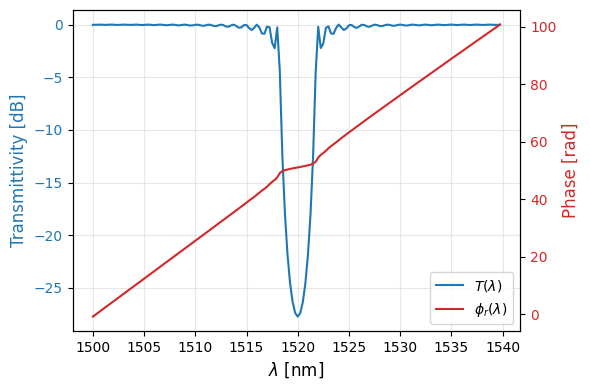

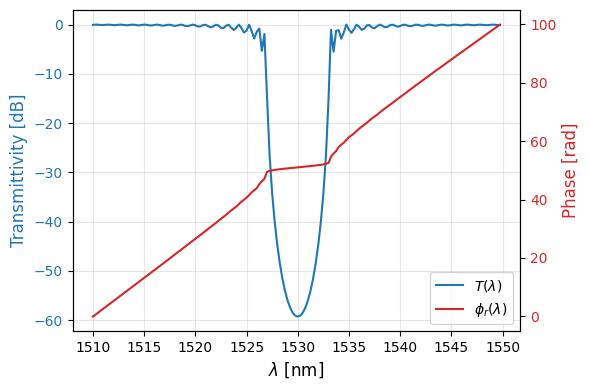

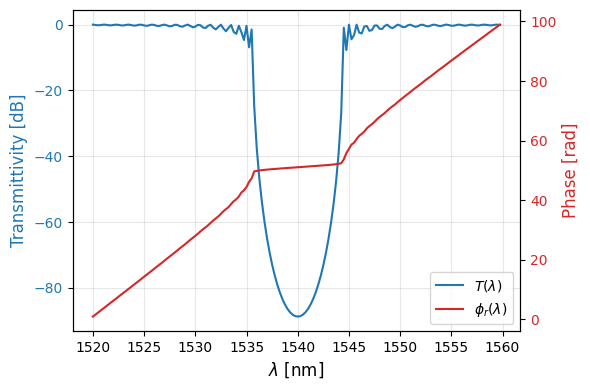

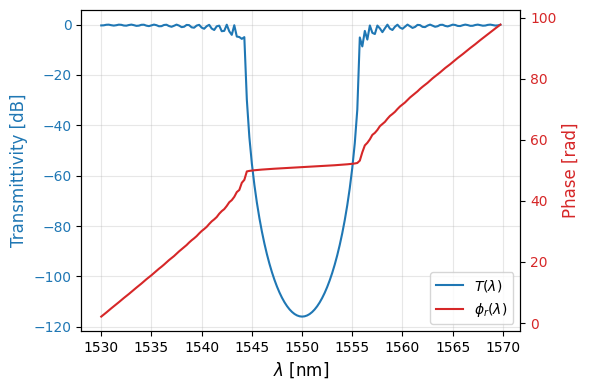

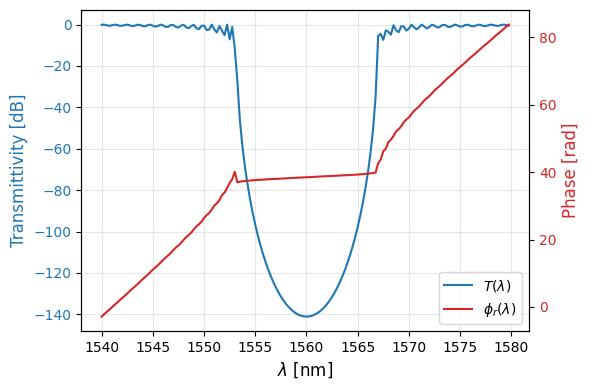

/tmp/ipykernel_181390/1981365017.py:11: RuntimeWarning: divide by zero encountered in arctanh
  kappaL_u1_v2.append(np.arctanh(np.sqrt(1 - 10**(T_min_u1[i]/10))))


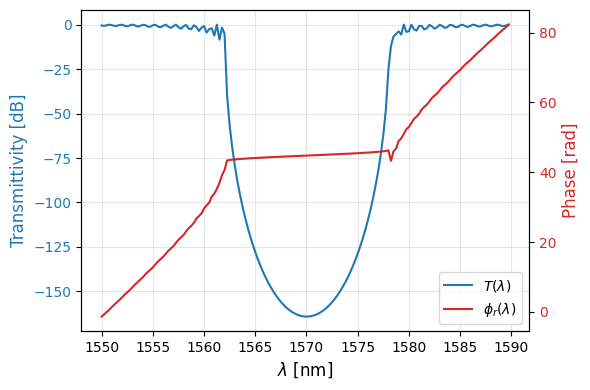

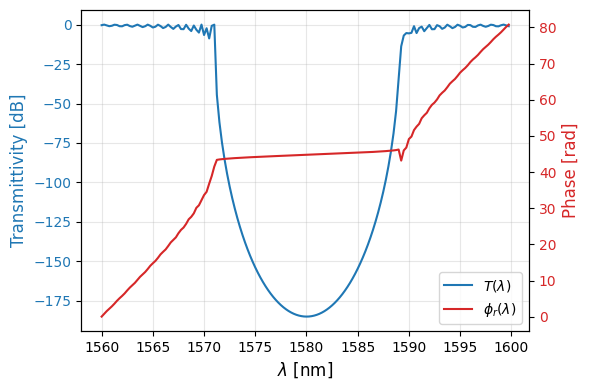

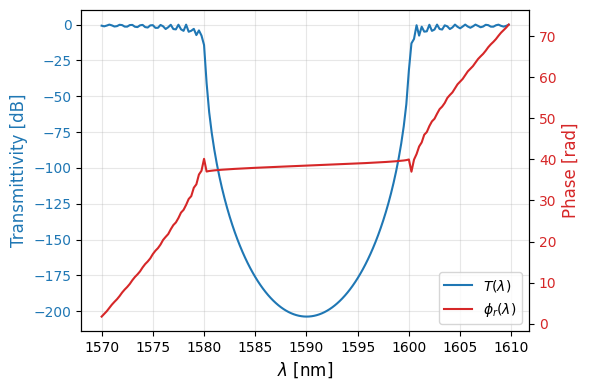

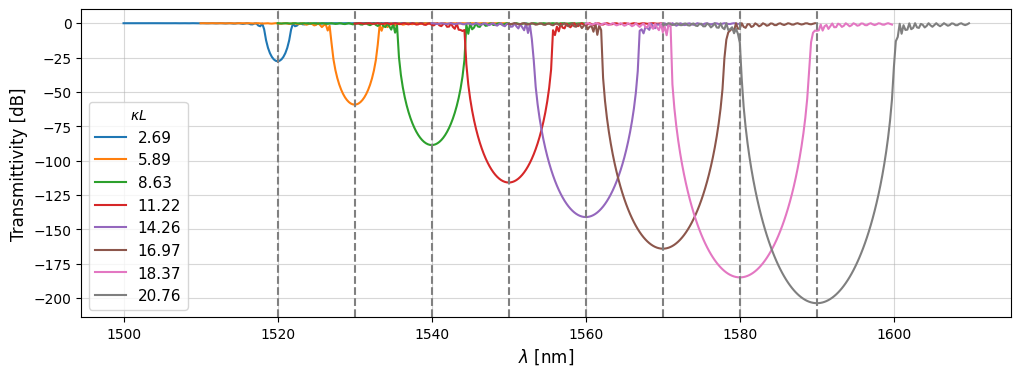

dW [ 25.  50.  75. 100. 125. 150. 175. 200.] nm
wl [1520 1530 1540 1550 1560 1570 1580 1590] nm
Period [494.51 497.64 500.82 504.06 507.34 510.69 514.08 517.53] nm
BW [ 4.    6.5   9.   11.5  14.5  17.25 18.75 21.25] nm
kappa [ 5.43 11.83 17.22 22.27 28.1  33.23 35.74 40.11] 1/mm
kappaL [ 2.69  5.89  8.63 11.22 14.26 16.97 18.37 20.76]
T_min [ -28.  -59.  -89. -116. -141. -164. -185. -204.] dB


NameError: name 'T_u1_fab' is not defined

In [ ]:
bw_u1, kappa_u1_v2, T_min_u1, kappaL_u1, kappaL_u1_v2 = [], [], [], [], []

for i, wl in enumerate(wl_u1):
    wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.25)*1e-9
    idx_min, wl_min = find_minima_sides(wavelength_test, np.array(T_u1[i]), distance=2)
    L = period_array_u1[i]*1e-6*N_u1
    bw_u1.append(np.abs(wl_min[0] - wl_min[1]))
    kappa_u1_v2.append(np.pi*np.sqrt((n_avg_u1[i]*bw_u1[i]/((wl*1e-9)**2))**2 - 1/(L**2)))
    T_min_u1.append(min(10*np.log10(np.array(T_u1[i]))))
    kappaL_u1.append(kappa_u1_v2[i]*L)
    kappaL_u1_v2.append(np.arctanh(np.sqrt(1 - 10**(T_min_u1[i]/10))))

    fig, ax1 = plt.subplots(figsize=(6, 4))
    color = 'tab:blue'
    ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
    ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
    line1 = ax1.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u1[i])), label=r'$T(\lambda)$', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.ticklabel_format(useOffset=False, axis='y') 
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color2 = 'tab:red'
    ax2.set_ylabel('Phase [rad]', color=color2, fontsize=12)
    line2 = ax2.plot(wavelength_test*1e9, phi_r_u1[i], color=color2, label=r'$\phi_r(\lambda)$')
    ax2.tick_params(axis='y', labelcolor=color2)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=10, loc='lower right')
    plt.tight_layout()

    # if wl==1560:
    #     plt.savefig("U1_example.png", dpi=300, bbox_inches="tight")
    
    plt.show()

plt.figure(figsize=(12, 4))
for k in range(len(wl_u1)):
    wavelength_test = np.arange(wl_u1[k]-window_size, wl_u1[k]+window_size, 0.25)*1e-9
    plt.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u1[k])), label=f'{kappaL_u1[k]:.2f}')
    plt.axvline(x=wl_u1[k], color='gray', linestyle='--')

#plt.title(f'U1 Transmittivity (n={n_u1})')
plt.xlabel(fr'$\lambda$ [nm]', fontsize=12)
plt.ylabel('Transmittivity [dB]', fontsize=12)
plt.legend(fontsize=11, title=r'$\kappa L$')
plt.grid(which='both', alpha=0.5)
#plt.savefig("U1_spectra_BCB.png", dpi=300, bbox_inches="tight")
plt.show()

print('dW', np.array(dwidth[1:])*1e3, 'nm')
print('wl', np.array(wl_u1), 'nm')
print('Period', np.round(np.array(period_array_u1)*1e3, 2), 'nm')
print('BW', np.round(np.array(bw_u1)*1e9, 2), 'nm')
print('kappa', np.round(np.array(kappa_u1_v2)*1e-3, 2), '1/mm')
print('kappaL', np.round(np.array(kappaL_u1), 2))
print('T_min', np.round(np.array(T_min_u1), 0), 'dB')

bw_u1_fab, kappa_u1_fab, T_min_u1_fab, kappaL_u1_fab, kappaL_u1_v2_fab = [], [], [], [], []

for j, wl in enumerate(wl_u1):
    wavelength_test = np.arange(wl_u1[j]-window_size, wl_u1[j]+window_size, 0.25)*1e-9
    idx_min, wl_min = find_minima_sides(wavelength_test, np.array(T_u1_fab[j]), distance=2)
    bw_u1_fab.append(np.abs(wl_min[0] - wl_min[1]))
    L = period_array_u1[j]*1e-6*N_u1
    kappa_u1_fab.append(np.pi*np.sqrt((n_avg_u1[j]*bw_u1_fab[j]/((wl*1e-9)**2))**2 - 1/(L**2)))
    T_min_u1_fab.append(min(10*np.log10(np.array(T_u1_fab[j]))))
    kappaL_u1_fab.append(kappa_u1_fab[j]*period_array_u1[j]*1e-6*N_u1)
    kappaL_u1_v2_fab.append(np.arctanh(np.sqrt(1 - 10**(T_min_u1_fab[j]/10))))

    fig, ax1 = plt.subplots(figsize=(6, 4))
    color = 'tab:blue'
    ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
    ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
    line1 = ax1.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u1_fab[j])), label=r'$T(\lambda)$', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.ticklabel_format(useOffset=False, axis='y') 
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Phase [rad]', color=color, fontsize=12)
    line2 = ax2.plot(wavelength_test*1e9, phi_r_u1_fab[j], color=color, label=r'$\phi_r(\lambda)$')
    ax2.tick_params(axis='y', labelcolor=color)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=10, loc='lower right')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 4))
for l in range(len(wl_u1)):
    wavelength_test = np.arange(wl_u1[l]-window_size, wl_u1[l]+window_size, 0.25)*1e-9
    plt.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u1_fab[l])), label=f'{kappaL_u1_fab[l]:.2f}')
    plt.axvline(x=wl_u1[l], color='gray', linestyle='--')

plt.title(f'U1 Transmittivity (n={n_u1_fab}) (Predicted)')
plt.xlabel(fr'$\lambda$ [nm]')
plt.ylabel('Transmittivity [dB]')
plt.legend(fontsize=10, title=r'$\kappa L$')
plt.grid()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter((width[1:] - width_0)/2*1e3, np.array(bw_u1)*1e9, color='r', label='Design')
axs[0].scatter((width[1:] - width_0)/2*1e3, np.array(bw_u1_fab)*1e9, color='b', label='Prediction')
axs[0].set_title('Bandwidth U1')
axs[0].set_ylabel(r'Bandwidth [nm]')
axs[0].set_xlabel('Corrugation [nm]')
axs[0].grid()
axs[0].legend()

axs[1].scatter((width[1:] - width_0)/2*1e3, kappa_u1_v2, color='r', label='Design')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappa_u1_fab, color='b', label='Prediction')
axs[1].set_title('Coupling Coefficient U1')
axs[1].set_ylabel(r'$\kappa$ [$m^{-1}$]')
axs[1].set_xlabel('Corrugation [nm]')
axs[1].grid()
axs[1].legend()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(kappaL_u1, T_min_u1, color='r', label='Design')
axs[0].scatter(kappaL_u1_fab, T_min_u1_fab, color='b', label='Prediction')
axs[0].set_xlabel(r'$\kappa L$')
axs[0].set_ylabel('Minimum Transmittivity [dB]')
axs[0].set_title(f'Minimum Transmittivity for N={N_u1}')
axs[0].grid()
axs[0].legend()

axs[1].scatter((width[1:] - width_0)/2*1e3, kappa_u1*np.array(period_array_u1)*1e-6*N_u1, color='r', label='Design')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u1, color='b', label='Design (BW)')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u1_v2, color='g', label='Design (R_max)')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u1_fab, color='orange', label='Lithography')
axs[1].set_xlabel('Corrugation [nm]')
axs[1].set_ylabel(r'$\kappa L$')
axs[1].set_title(fr'$\kappa L$ for N={N_u1}')
axs[1].grid()
axs[1].legend()
plt.show()

plt.scatter(kappaL_u1_fab, kappaL_u1, color='b')
plt.title(r'$\kappa L$ Before and After Fabrication')
plt.xlabel(r'$\kappa L$ Design')
plt.ylabel(r'$\kappa L$ Fabrication')
plt.grid()
plt.show()


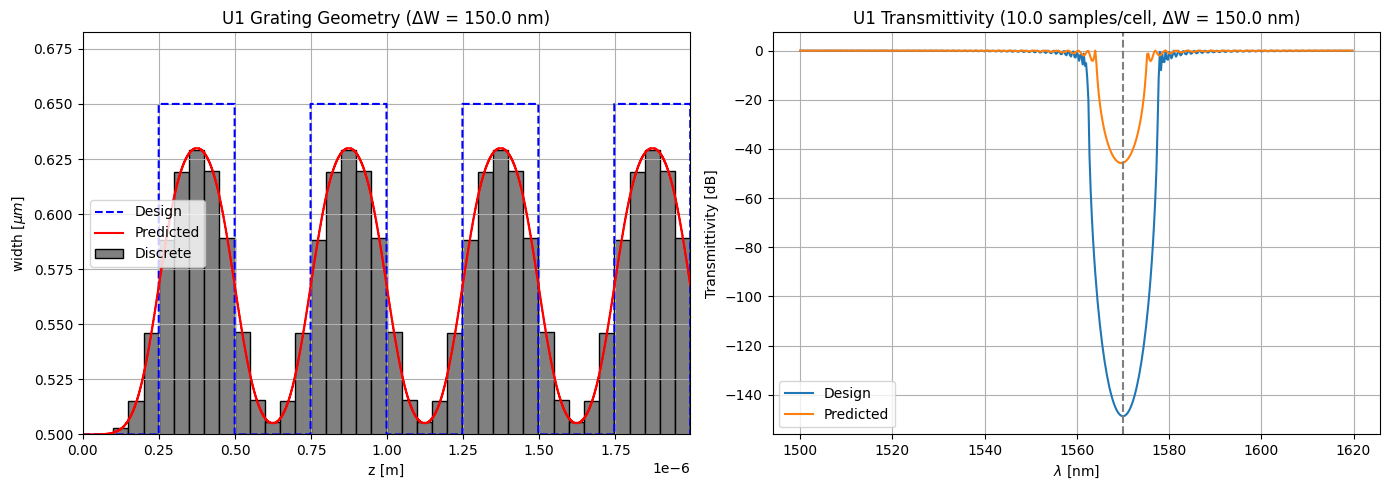

In [ ]:
# Comparison between designed and predicted Bragg gratings
k = 5

wavelength_test = np.arange(1500, 1620, 0.25)*1e-9
M = 10*N_u1
dwidth_1 = 0.0
L = N_u1*period_array_u1[k]*1e-6
dz = L/M

z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u1[k]*1e-6, dwidth[k+1], N_u1, duty=0.5, dL=0)
z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M)
w_mean = dw_mean_p - dw_mean_n + width_0

M_wl = Bragg_grating(wavelength_test, w_mean, dz, M, popt_wl, popt_w)
T = []
for j in range(len(wavelength_test)):
    T.append(1/(np.abs(M_wl[j][0, 0])**2))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[1].plot(wavelength_test*1e9, 10*np.log10(T), label='Design')

sigma_test = 60*1e-9
loss_test = 0.9

dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma_test, dw_real_p, dw_real_n, loss_test)
z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M)
w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

M_wl = Bragg_grating(wavelength_test, w_mean_fab, dz, M//2, popt_wl, popt_w)
T = []
for j in range(len(wavelength_test)):
    T.append(1/(np.abs(M_wl[j][0, 0])**2))

axs[1].plot(wavelength_test*1e9, 10*np.log10(T), label='Predicted')
axs[1].axvline(x=wl_u1[k], color='gray', linestyle='--')
axs[1].set_title(f'U1 Transmittivity ({M/N_u1} samples/cell, ΔW = {dwidth[k+1]*1e3:.1f} nm)')
axs[1].set_xlabel(fr'$\lambda$ [nm]')
axs[1].set_ylabel('Transmittivity [dB]')
axs[1].legend()
axs[1].grid()

axs[0].step(z_real, dw_real_p + width_0/2, where='post', label='Design', color='blue', linestyle='--')
axs[0].step(z_real, dw_fab_p + width_0/2, where='post', label='Predicted', color='red')
axs[0].bar(z_edges_fab[:-1] + (z_edges_fab[1] - z_edges_fab[0])/2, dw_mean_fab_p + width_0/2, width=(z_edges_fab[1] - z_edges_fab[0]), color='grey', edgecolor='black', label='Discrete')
axs[0].set_title(f'U1 Grating Geometry (ΔW = {dwidth[k+1]*1e3:.1f} nm)')
axs[0].set_xlabel('z [m]')
axs[0].set_ylabel(r'width $[\mu m]$')
axs[0].set_xlim(0, 4*period_array_u1[k]*1e-6)
axs[0].set_ylim(width_0/2)
axs[0].legend()
axs[0].grid()

plt.tight_layout()
plt.show()

# U2

## Period Calculation

U2 parameters 

λ   = [1530 1540 1550 1560 1570 1580] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150.] (nm)
Λ   = [498.54817136 501.67392744 504.8509589  508.08024049 511.36277939
 514.69961629] (nm)


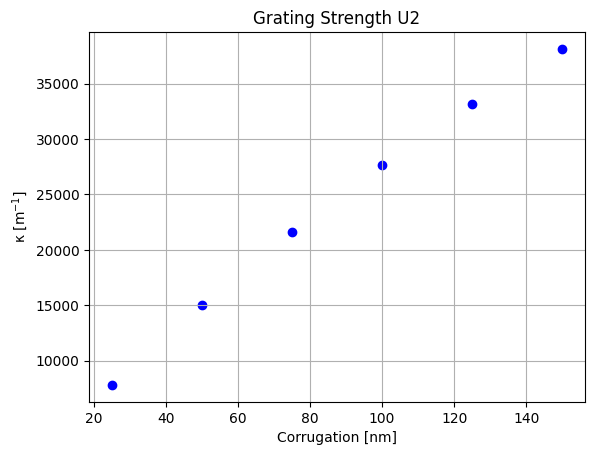

In [11]:
# Obtain the grating period for each U2 Bragg grating
period_array_u2 = []
n1_array = []
n2_array = []
n_avg_u2 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u2:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u2.append(float(n_avg))
    period_array_u2.append(float(period*1e-3))
    i+=1

print('U2 parameters \n')
print(f'λ   = {wl_u2} (nm)')
print(f'ΔW  = {(width[1:7] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u2)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u2 = 2*delta_n/(wl_u2*1e-9)
plt.scatter((width[1:7] - width_0)/2*1e3, kappa_u2, color='b')

plt.title('Grating Strength U2')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

## TMM Simulation

In [29]:
# TMM Simulation
n_u2 = 1
M_u2 = n_u2*(2*N_u2)

T_u2 = []
phi_r_u2 = []
phi_t_u2 = []
tau_r_u2 = []
tau_t_u2 = []

for i in range(len(period_array_u2)):
    t_inicio = time.perf_counter()
    L = N_u2*period_array_u2[i]*1e-6
    dz = L/M_u2

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u2[i]*1e-6, dwidth[i+1], N_u2, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u2)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test = np.arange(wl_u2[i]-window_size, wl_u2[i]+window_size, 0.25)*1e-9
    M_wl = Bragg_grating(wavelength_test, w_mean, dz, M_u2, popt_wl, popt_w)
    
    T_buff = []
    phi_r_buff = []
    phi_t_buff = []
    
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        phi_r_buff.append(np.angle(1/M_wl[j][0, 0]))
        phi_t_buff.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))


    aux = wavelength_test**2/(2*np.pi*3e8)
    tau_r_buff = aux*np.gradient(np.unwrap(np.array(phi_r_buff)), wavelength_test)
    tau_t_buff = aux*np.gradient(np.unwrap(np.array(phi_t_buff)), wavelength_test)

    T_u2.append(T_buff)
    phi_r_u2.append(np.unwrap(np.array(phi_r_buff)))
    phi_t_u2.append(np.unwrap(np.array(phi_t_buff)))
    tau_r_u2.append(tau_r_buff)
    tau_t_u2.append(tau_t_buff)

    t_final = time.perf_counter()
    print(f'Time for TMM simulation {i}: {t_final - t_inicio:.2f} s')

Time for TMM simulation 0: 5.96 s
Time for TMM simulation 1: 6.23 s
Time for TMM simulation 2: 6.12 s
Time for TMM simulation 3: 5.90 s
Time for TMM simulation 4: 5.93 s
Time for TMM simulation 5: 6.06 s


In [ ]:
# TMM Simulation with lithography prediction
n_u2_fab = 15
M_u2_fab = n_u2_fab*(2*N_u2)

T_u2_fab = []
phi_r_u2_fab = []
phi_t_u2_fab = []
tau_r_u2_fab = []
tau_t_u2_fab = []

for i in range(len(period_array_u2)):
    t_inicio = time.perf_counter()
    L = N_u2*period_array_u2[i]*1e-6
    dz = L/M_u2_fab

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u2[i]*1e-6, dwidth[i+1], N_u2, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u2_fab)

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u2_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = np.arange(wl_u2[i]-window_size, wl_u2[i]+window_size, 0.25)*1e-9
    M_wl = Bragg_grating(wavelength_test, w_mean_fab, dz, M_u2_fab, popt_wl, popt_w)
    
    T_buff = []
    phi_r_buff = []
    phi_t_buff = []
    
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        phi_r_buff.append(np.angle(1/M_wl[j][0, 0]))
        phi_t_buff.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))


    aux = wavelength_test**2/(2*np.pi*3e8)
    tau_r_buff = aux*np.gradient(np.unwrap(np.array(phi_r_buff)), wavelength_test)
    tau_t_buff = aux*np.gradient(np.unwrap(np.array(phi_t_buff)), wavelength_test)

    T_u2_fab.append(T_buff)
    phi_r_u2_fab.append(np.unwrap(np.array(phi_r_buff)))
    phi_t_u2_fab.append(np.unwrap(np.array(phi_t_buff)))
    tau_r_u2_fab.append(tau_r_buff)
    tau_t_u2_fab.append(tau_t_buff)

    t_final = time.perf_counter()
    print(f'Time for TMM simulation {i}: {t_final - t_inicio:.2f} s')

## Results

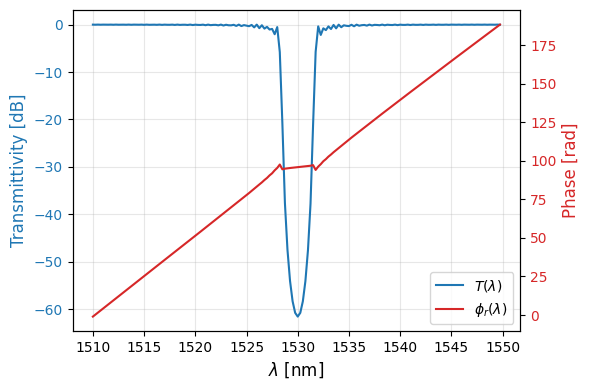

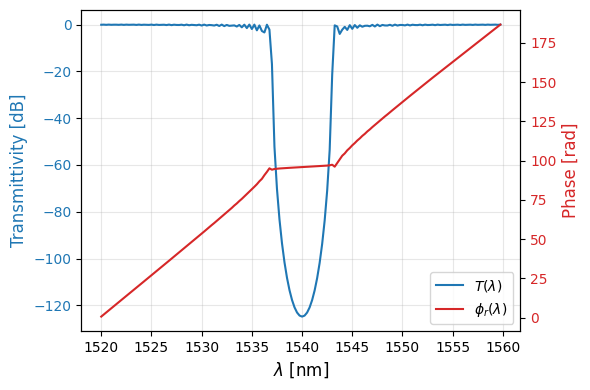

/tmp/ipykernel_181390/2891498014.py:11: RuntimeWarning: divide by zero encountered in arctanh
  kappaL_u2_v2.append(np.arctanh(np.sqrt(1 - 10**(T_min_u2[i]/10))))


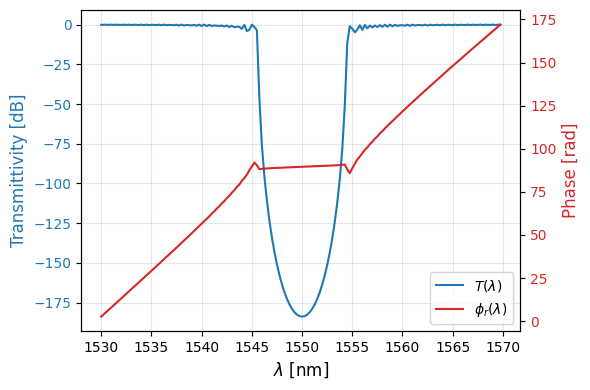

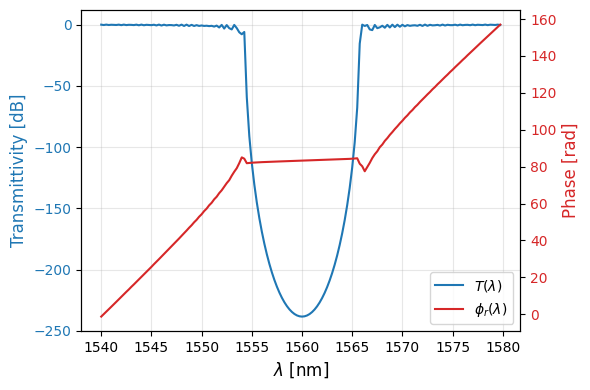

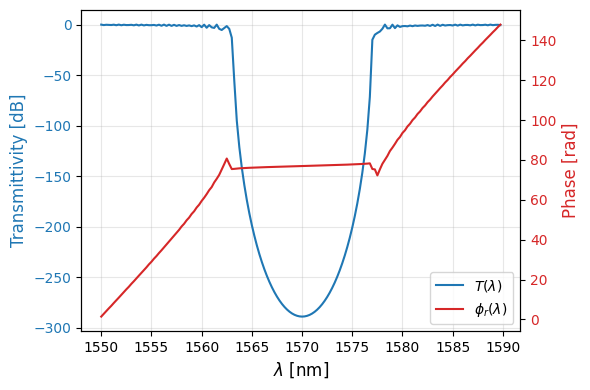

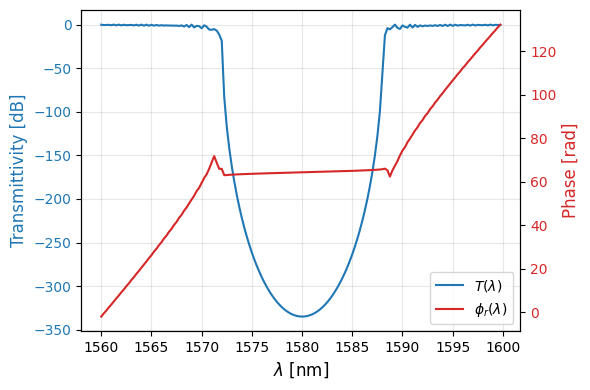

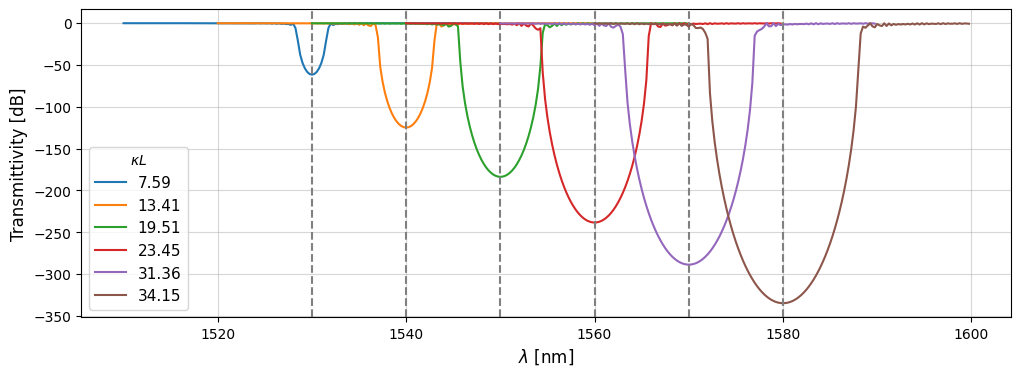

dW [ 25.  50.  75. 100. 125. 150.] nm
wl [1530 1540 1550 1560 1570 1580] nm
Period [498.55 501.67 504.85 508.08 511.36 514.7 ] nm
BW [ 4.    6.75  9.75 11.75 15.75 17.25] nm
kappa [ 7.61 13.36 19.32 23.08 30.66 33.18] 1/mm
kappaL [ 7.59 13.41 19.51 23.45 31.36 34.15]
T_min [ -62. -125. -184. -238. -289. -335.] dB


NameError: name 'T_u2_fab' is not defined

In [ ]:
bw_u2, kappa_u2_v2, T_min_u2, kappaL_u2, kappaL_u2_v2 = [], [], [], [], []

for i, wl in enumerate(wl_u2):
    wavelength_test = np.arange(wl_u2[i]-window_size, wl_u2[i]+window_size, 0.25)*1e-9
    idx_min, wl_min = find_minima_sides(wavelength_test, np.array(T_u2[i]), distance=2)
    L = period_array_u2[i]*1e-6*N_u2
    bw_u2.append(np.abs(wl_min[0] - wl_min[1]))
    kappa_u2_v2.append(np.pi*np.sqrt((n_avg_u2[i]*bw_u2[i]/((wl*1e-9)**2))**2 - 1/(L**2)))
    T_min_u2.append(min(10*np.log10(np.array(T_u2[i]))))
    kappaL_u2.append(kappa_u2_v2[i]*L)
    kappaL_u2_v2.append(np.arctanh(np.sqrt(1 - 10**(T_min_u2[i]/10))))


    fig, ax1 = plt.subplots(figsize=(6, 4))
    color = 'tab:blue'
    ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
    ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
    line1 = ax1.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u2[i])), label=r'$T(\lambda)$', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.ticklabel_format(useOffset=False, axis='y') 
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Phase [rad]', color=color, fontsize=12)
    line2 = ax2.plot(wavelength_test*1e9, phi_r_u2[i], color=color, label=r'$\phi_r(\lambda)$')
    ax2.tick_params(axis='y', labelcolor=color)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right', fontsize=10)
    plt.tight_layout()

    if wl==1560:
        plt.savefig("U2_example.png", dpi=300, bbox_inches="tight")

    plt.show()

plt.figure(figsize=(12, 4))
for k in range(len(wl_u2)):
    wavelength_test = np.arange(wl_u2[k]-window_size, wl_u2[k]+window_size, 0.25)*1e-9
    plt.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u2[k])), label=f'{kappaL_u2[k]:.2f}')
    plt.axvline(x=wl_u2[k], color='gray', linestyle='--')

#plt.title(f'U2 Transmittivity (n={n_u2}) (Design)')
plt.xlabel(fr'$\lambda$ [nm]', fontsize=12)
plt.ylabel('Transmittivity [dB]', fontsize=12)
plt.legend(fontsize=11, title=r'$\kappa L$')
plt.grid(which='both', alpha=0.5)
#plt.savefig("U2_spectra_BCB.png", dpi=300, bbox_inches="tight")
plt.show()

print('dW', np.array(dwidth[1:7])*1e3, 'nm')
print('wl', np.array(wl_u2), 'nm')
print('Period', np.round(np.array(period_array_u2)*1e3, 2), 'nm')
print('BW', np.round(np.array(bw_u2)*1e9, 2), 'nm')
print('kappa', np.round(np.array(kappa_u2_v2)*1e-3, 2), '1/mm')
print('kappaL', np.round(np.array(kappaL_u2), 2))
print('T_min', np.round(np.array(T_min_u2), 0), 'dB')

bw_u2_fab, kappa_u2_fab, T_min_u2_fab, kappaL_u2_fab, kappaL_u2_v2_fab = [], [], [], [], []

for j, wl in enumerate(wl_u2):
    wavelength_test = np.arange(wl_u2[j]-window_size, wl_u2[j]+window_size, 0.25)*1e-9
    idx_min, wl_min = find_minima_sides(wavelength_test, np.array(T_u2_fab[j]), distance=2)
    bw_u2_fab.append(np.abs(wl_min[0] - wl_min[1]))
    L = period_array_u2[j]*1e-6*N_u2
    kappa_u2_fab.append(np.pi*np.sqrt((n_avg_u2[j]*bw_u2_fab[j]/((wl*1e-9)**2))**2 - 1/(L**2)))
    T_min_u2_fab.append(min(10*np.log10(np.array(T_u2_fab[j]))))
    kappaL_u2_fab.append(kappa_u2_fab[j]*period_array_u2[j]*1e-6*N_u2)
    kappaL_u2_v2_fab.append(np.arctanh(np.sqrt(1 - 10**(T_min_u2_fab[j]/10))))

    fig, ax1 = plt.subplots(figsize=(6, 4))
    color = 'tab:blue'
    ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
    ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
    line1 = ax1.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u2_fab[j])), label=r'$T(\lambda)$', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.ticklabel_format(useOffset=False, axis='y') 
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Phase [rad]', color=color, fontsize=12)
    line2 = ax2.plot(wavelength_test*1e9, phi_r_u2_fab[j], color=color, label=r'$\phi_r(\lambda)$')
    ax2.tick_params(axis='y', labelcolor=color)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 4))
for l in range(len(wl_u2)):
    wavelength_test = np.arange(wl_u2[l]-window_size, wl_u2[l]+window_size, 0.25)*1e-9
    plt.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u2_fab[l])), label=f'{kappaL_u2_fab[l]:.2f}')
    plt.axvline(x=wl_u2[l], color='gray', linestyle='--')

plt.title(f'U2 Transmittivity (N={n_u2_fab}) (Predicted)')
plt.xlabel(fr'$\lambda$ [nm]')
plt.ylabel('Transmittivity [dB]')
plt.legend(fontsize=10, title=r'$\kappa L$')
plt.grid()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter((width[1:7] - width_0)/2*1e3, np.array(bw_u2)*1e9, color='r', label='Design')
axs[0].scatter((width[1:7] - width_0)/2*1e3, np.array(bw_u2_fab)*1e9, color='b', label='Prediction')
axs[0].set_title('Bandwidth U2')
axs[0].set_ylabel(r'Bandwidth [nm]')
axs[0].set_xlabel('Corrugation [nm]')
axs[0].grid()
axs[0].legend()

axs[1].scatter((width[1:7] - width_0)/2*1e3, kappa_u2_v2, color='r', label='Design')
axs[1].scatter((width[1:7] - width_0)/2*1e3, kappa_u2_fab, color='b', label='Prediction')
axs[1].set_title('Coupling Coefficient U2')
axs[1].set_ylabel(r'$\kappa$ [$m^{-1}$]')
axs[1].set_xlabel('Corrugation [nm]')
axs[1].grid()
axs[1].legend()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(kappaL_u2, T_min_u2, color='r', label='Design')
axs[0].scatter(kappaL_u2_fab, T_min_u2_fab, color='b', label='Prediction')
axs[0].set_xlabel(r'$\kappa L$')
axs[0].set_ylabel('Minimum Transmittivity [dB]')
axs[0].set_title(f'Minimum Transmittivity for N={N_u2}')
axs[0].grid()
axs[0].legend()

axs[1].scatter((width[1:] - width_0)/2*1e3, kappa_u2*np.array(period_array_u2)*1e-6*N_u2, color='r', label='Design')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u2, color='b', label='Design (BW)')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u2_v2, color='g', label='Design (R_max)')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u2_fab, color='o', label='Lithography')
axs[1].set_xlabel('Corrugation [nm]')
axs[1].set_ylabel(r'$\kappa L$')
axs[1].set_title(fr'$\kappa L$ for N={N_u2}')
axs[1].grid()
axs[1].legend()
plt.show()

plt.scatter(kappaL_u2_fab, kappaL_u2, color='b')
plt.title(r'$\kappa L$ Before and After Fabrication')
plt.xlabel(r'$\kappa L$ Design')
plt.ylabel(r'$\kappa L$ Fabrication')
plt.grid()

# U3

## Period Calculation

U3 parameters 

λ   = [1530 1540 1550 1560] (nm)
ΔW  = [ 50.  75. 100. 125.] (nm)
Λ   = [497.64142118 500.82363834 504.05772417 507.34468885] (nm)


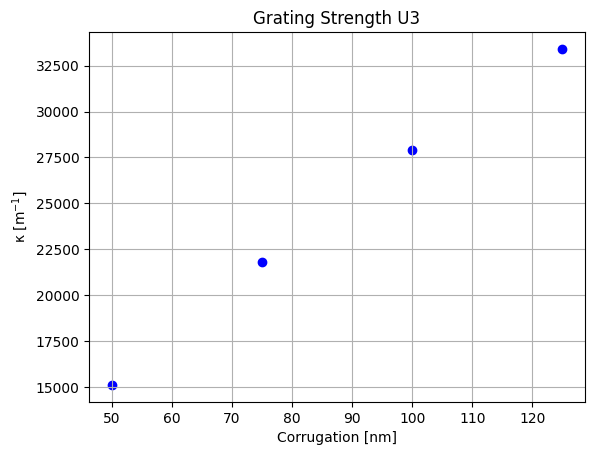

In [12]:
# Obtain the grating period for each U3 Bragg grating
period_array_u3 = []
n1_array = []
n2_array = []
n_avg_u3 = []

i = 2 # Start with a corrugation of 50 nm
for bragg_wl in wl_u3:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u3.append(float(n_avg))
    period_array_u3.append(float(period*1e-3))
    i+=1

print('U3 parameters \n')
print(f'λ   = {wl_u3} (nm)')
print(f'ΔW  = {(width[2:6] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u3)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u3 = 2*delta_n/(wl_u3*1e-9)
plt.scatter((width[2:6] - width_0)/2*1e3, kappa_u3, color='b')

plt.title('Grating Strength U3')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

## TMM Simulation

In [41]:
# TMM Simulation
n_u3 = 1
M_u3 = n_u3*(2*N_u3)

T_u3 = []
phi_r_u3 = []
phi_t_u3 = []
tau_r_u3 = []
tau_t_u3 = []

for i in range(len(period_array_u3)):
    t_inicio = time.perf_counter()
    L = N_u3*period_array_u3[i]*1e-6
    dz = L/M_u3

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u3[i]*1e-6, dwidth[i+2], N_u3, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u3)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test = np.arange(wl_u3[i]-window_size, wl_u3[i]+window_size, 0.25)*1e-9
    M_wl = Bragg_grating(wavelength_test, w_mean, dz, M_u3, popt_wl, popt_w)
    
    T_buff = []
    phi_r_buff = []
    phi_t_buff = []
    
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        phi_r_buff.append(np.angle(1/M_wl[j][0, 0]))
        phi_t_buff.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))


    aux = wavelength_test**2/(2*np.pi*3e8)
    tau_r_buff = aux*np.gradient(np.unwrap(np.array(phi_r_buff)), wavelength_test)
    tau_t_buff = aux*np.gradient(np.unwrap(np.array(phi_t_buff)), wavelength_test)

    T_u3.append(T_buff)
    phi_r_u3.append(np.unwrap(np.array(phi_r_buff)))
    phi_t_u3.append(np.unwrap(np.array(phi_t_buff)))
    tau_r_u3.append(tau_r_buff)
    tau_t_u3.append(tau_t_buff)

    t_final = time.perf_counter()
    print(f'Time for TMM simulation {i}: {t_final - t_inicio:.2f} s')

Time for TMM simulation 0: 23.40 s
Time for TMM simulation 1: 21.76 s
Time for TMM simulation 2: 22.81 s
Time for TMM simulation 3: 21.56 s


In [ ]:
# TMM Simulation with lithography prediction
n_u3_fab = 15
M_u3_fab = n_u3_fab*(2*N_u3)

T_u3_fab = []
phi_r_u3_fab = []
phi_t_u3_fab = []
tau_r_u3_fab = []
tau_t_u3_fab = []

for i in range(len(period_array_u3)):
    L = N_u3*period_array_u3[i]*1e-6
    dz = L/M_u3_fab

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u3[i]*1e-6, dwidth[i+2], N_u3, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u3_fab)

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u3_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = np.arange(wl_u3[i]-window_size, wl_u3[i]+window_size, 0.25)*1e-9
    M_wl = Bragg_grating(wavelength_test, w_mean_fab, dz, M_u3_fab, popt_wl, popt_w)
    
    T_buff = []
    phi_r_buff = []
    phi_t_buff = []
    
    for j in range(len(wavelength_test)):
        T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        phi_r_buff.append(np.angle(1/M_wl[j][0, 0]))
        phi_t_buff.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))


    aux = wavelength_test**2/(2*np.pi*3e8)
    tau_r_buff = aux*np.gradient(np.unwrap(np.array(phi_r_buff)), wavelength_test)
    tau_t_buff = aux*np.gradient(np.unwrap(np.array(phi_t_buff)), wavelength_test)

    T_u3_fab.append(T_buff)
    phi_r_u3_fab.append(np.unwrap(np.array(phi_r_buff)))
    phi_t_u3_fab.append(np.unwrap(np.array(phi_t_buff)))
    tau_r_u3_fab.append(tau_r_buff)
    tau_t_u3_fab.append(tau_t_buff)

KeyboardInterrupt: 

## Results

/tmp/ipykernel_181390/4164554875.py:11: RuntimeWarning: divide by zero encountered in arctanh
  kappaL_u3_v2.append(np.arctanh(np.sqrt(1 - 10**(T_min_u3[i]/10))))


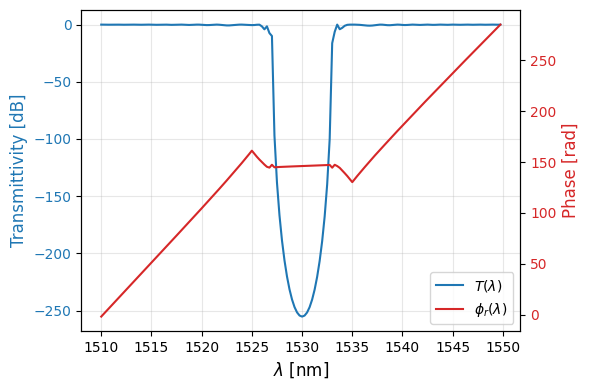

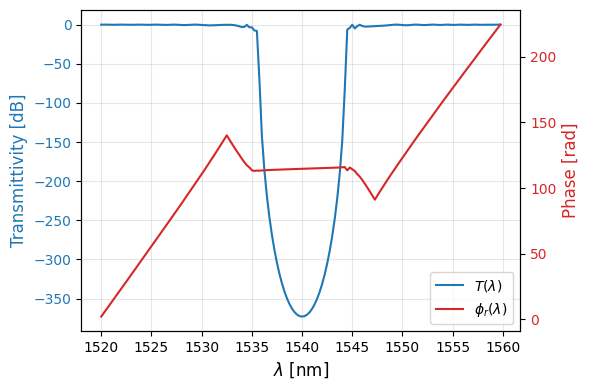

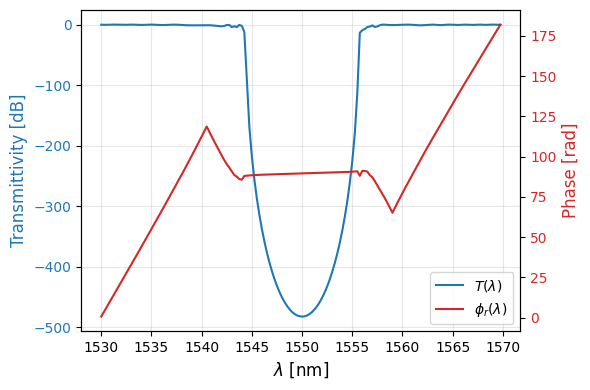

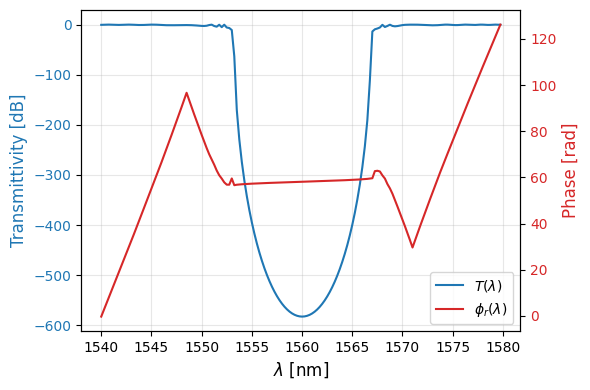

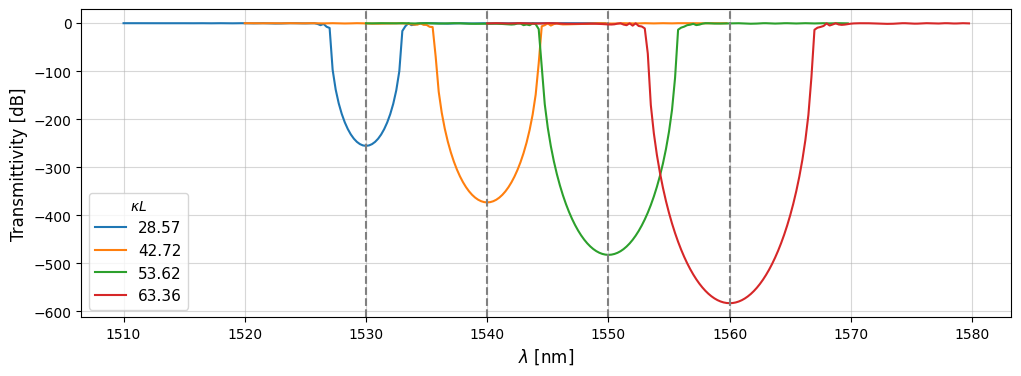

dW [ 50.  75. 100. 125.] nm
wl [1530 1540 1550 1560] nm
Period [497.64 500.82 504.06 507.34] nm
BW [ 7.   10.5  13.25 15.75] nm
kappa [14.35 21.33 26.59 31.22] 1/mm
kappaL [28.57 42.72 53.62 63.36]
T_min [-255. -373. -482. -583.] dB


NameError: name 'T_u3_fab' is not defined

In [ ]:
bw_u3, kappa_u3_v2, T_min_u3, kappaL_u3, kappaL_u3_v2 = [], [], [], [], []

for i, wl in enumerate(wl_u3):
    wavelength_test = np.arange(wl_u3[i]-window_size, wl_u3[i]+window_size, 0.25)*1e-9
    idx_min, wl_min = find_minima_sides(wavelength_test, np.array(T_u3[i]), distance=2)
    L = period_array_u3[i]*1e-6*N_u3
    bw_u3.append(np.abs(wl_min[0] - wl_min[1]))
    kappa_u3_v2.append(np.pi*np.sqrt((n_avg_u3[i]*bw_u3[i]/((wl*1e-9)**2))**2 - 1/(L**2)))
    T_min_u3.append(min(10*np.log10(np.array(T_u3[i]))))
    kappaL_u3.append(kappa_u3_v2[i]*L)
    kappaL_u3_v2.append(np.arctanh(np.sqrt(1 - 10**(T_min_u3[i]/10))))


    fig, ax1 = plt.subplots(figsize=(6, 4))
    color = 'tab:blue'
    ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
    ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
    line1 = ax1.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u3[i])), label=r'$T(\lambda)$', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.ticklabel_format(useOffset=False, axis='y') 
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Phase [rad]', color=color, fontsize=12)
    line2 = ax2.plot(wavelength_test*1e9, phi_r_u3[i], color=color, label=r'$\phi_r(\lambda)$')
    ax2.tick_params(axis='y', labelcolor=color)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 4))
for k in range(len(wl_u3)):
    wavelength_test = np.arange(wl_u3[k]-window_size, wl_u3[k]+window_size, 0.25)*1e-9
    plt.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u3[k])), label=f'{kappaL_u3[k]:.2f}')
    plt.axvline(x=wl_u3[k], color='gray', linestyle='--')

#plt.title(f'U3 Transmittivity (n={n_u3}) (Design)')
plt.xlabel(fr'$\lambda$ [nm]', fontsize=12)
plt.ylabel('Transmittivity [dB]', fontsize=12)
plt.legend(fontsize=11, title=r'$\kappa L$')
plt.grid(which='both', alpha=0.5)
#plt.savefig("U3_spectra_BCB.png", dpi=300, bbox_inches="tight")
plt.show()

print('dW', np.array(dwidth[2:6])*1e3, 'nm')
print('wl', np.array(wl_u3), 'nm')
print('Period', np.round(np.array(period_array_u3)*1e3, 2), 'nm')
print('BW', np.round(np.array(bw_u3)*1e9, 2), 'nm')
print('kappa', np.round(np.array(kappa_u3_v2)*1e-3, 2), '1/mm')
print('kappaL', np.round(np.array(kappaL_u3), 2))
print('T_min', np.round(np.array(T_min_u3), 0), 'dB')

bw_u3_fab, kappa_u3_fab, T_min_u3_fab, kappaL_u3_fab, kappaL_u3_v2_fab = [], [], [], [], []

for j, wl in enumerate(wl_u3):
    wavelength_test = np.arange(wl_u3[j]-window_size, wl_u3[j]+window_size, 0.25)*1e-9
    idx_min, wl_min = find_minima_sides(wavelength_test, np.array(T_u3_fab[j]), distance=2)
    bw_u3_fab.append(np.abs(wl_min[0] - wl_min[1]))
    L = period_array_u3[j]*1e-6*N_u3
    kappa_u3_fab.append(np.pi*np.sqrt((n_avg_u3[j]*bw_u3_fab[j]/((wl*1e-9)**2))**2 - 1/(L**2)))
    T_min_u3_fab.append(min(10*np.log10(np.array(T_u3_fab[j]))))
    kappaL_u3_fab.append(kappa_u3_fab[j]*period_array_u3[j]*1e-6*N_u3)
    kappaL_u3_v2_fab.append(np.arctanh(np.sqrt(1 - 10**(T_min_u3_fab[j]/10))))

    fig, ax1 = plt.subplots(figsize=(6, 4))
    color = 'tab:blue'
    ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
    ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
    line1 = ax1.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u3_fab[j])), label=r'$T(\lambda)$', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.ticklabel_format(useOffset=False, axis='y') 
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Phase [rad]', color=color, fontsize=12)
    line2 = ax2.plot(wavelength_test*1e9, phi_r_u3_fab[j], color=color, label=r'$\phi_r(\lambda)$')
    ax2.tick_params(axis='y', labelcolor=color)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 4))
for l in range(len(wl_u3)):
    wavelength_test = np.arange(wl_u3[l]-window_size, wl_u3[l]+window_size, 0.25)*1e-9
    plt.plot(wavelength_test*1e9, 10*np.log10(np.array(T_u3_fab[l])), label=f'{kappaL_u3_fab[l]:.2f}')
    plt.axvline(x=wl_u3[l], color='gray', linestyle='--')

plt.title(f'U3 Transmittivity (n={n_u3_fab} samples/cell) (Predicted)')
plt.xlabel(fr'$\lambda$ [nm]')
plt.ylabel('Transmittivity [dB]')
plt.legend(fontsize=10, title=r'$\kappa L$')
plt.grid()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter((width[2:6] - width_0)/2*1e3, np.array(bw_u3)*1e9, color='r', label='Design')
axs[0].scatter((width[2:6] - width_0)/2*1e3, np.array(bw_u3_fab)*1e9, color='b', label='Prediction')
axs[0].set_title('Bandwidth U3')
axs[0].set_ylabel(r'Bandwidth [nm]')
axs[0].set_xlabel('Corrugation [nm]')
axs[0].grid()
axs[0].legend()

axs[1].scatter((width[2:6] - width_0)/2*1e3, kappa_u3_v2, color='r', label='Design')
axs[1].scatter((width[2:6] - width_0)/2*1e3, kappa_u3_fab, color='b', label='Prediction')
axs[1].set_title('Coupling Coefficient U3')
axs[1].set_ylabel(r'$\kappa$ [$m^{-1}$]')
axs[1].set_xlabel('Corrugation [nm]')
axs[1].grid()
axs[1].legend()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(kappaL_u3, T_min_u3, color='r', label='Design')
axs[0].scatter(kappaL_u3_fab, T_min_u3_fab, color='b', label='Prediction')
axs[0].set_xlabel(r'$\kappa L$')
axs[0].set_ylabel('Minimum Transmittivity [dB]')
axs[0].set_title(f'Minimum Transmittivity for N={N_u3}')
axs[0].grid()
axs[0].legend()

axs[1].scatter((width[1:] - width_0)/2*1e3, kappa_u3*np.array(period_array_u3)*1e-6*N_u3, color='r', label='Design')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u3, color='b', label='Design (BW)')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u3_v2, color='g', label='Design (R_max)')
axs[1].scatter((width[1:] - width_0)/2*1e3, kappaL_u3_fab, color='o', label='Lithography')
axs[1].set_xlabel('Corrugation [nm]')
axs[1].set_ylabel(r'$\kappa L$')
axs[1].set_title(fr'$\kappa L$ for N={N_u3}')
axs[1].grid()
axs[1].legend()
plt.show()

plt.scatter(kappaL_u3_fab, kappaL_u3, color='b')
plt.title(r'$\kappa L$ Before and After Fabrication')
plt.xlabel(r'$\kappa L$ Design')
plt.ylabel(r'$\kappa L$ Fabrication')
plt.grid()

# Test

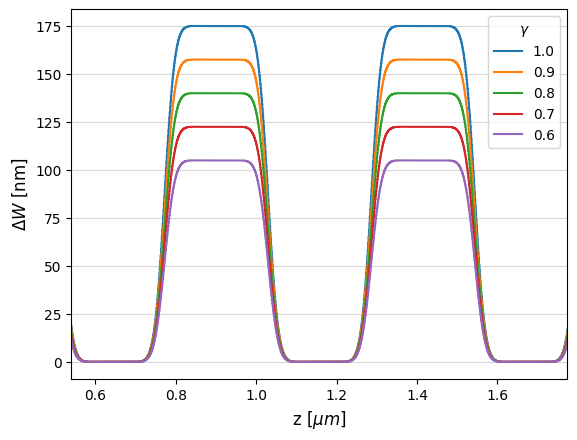

In [19]:
scale_array = np.arange(1.0, 0.5, -0.1)

N_test = 5
sigma = 20e-9
n_u1 = 2  
M_u1_fab = int(n_u1 * (2 * N_test))

# Fijamos i = 0
i = 6
L = N_test * period_array_u1[i] * 1e-6
dz = L / M_u1_fab

# Geometría de la red para i = 0
z_real, dw_real_p, dw_real_n = uniform_grating(
    period_array_u1[i] * 1e-6, 
    dwidth[i + 1], 
    N_test, 
    duty=0.5, 
    dL=0
)
z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1_fab)
    

for scale_factor in scale_array:
    t_inicio = time.perf_counter()  

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u1_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    plt.step(z_real*1e6, dw_fab_p*1e3, where='post', label=f'{np.round(scale_factor, 1):.1f}')
    #plt.axhline(np.mean(dw_fab_p + width_0/2)*1e3, color='k', linestyle='--', alpha=0.5)

plt.xlim(1.05*period_array_u1[i], 3.45*period_array_u1[i])
#plt.title(f'Grating Geometry Scaling={np.round(scale_factor, 2)*100}%')
plt.ylabel(r'$\Delta W$ [nm]', fontsize=12)
plt.xlabel(r'z $[\mu m]$', fontsize=12)
plt.legend(fontsize=10, loc='upper right', title=r'$\gamma$')
plt.grid(axis='y', alpha=0.5)
plt.savefig("grating_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

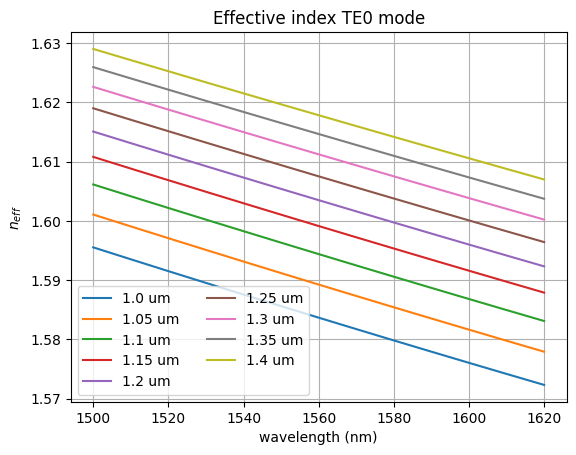

In [ ]:
# Extract Effective Indices from Modesolver results
dneff = []
n_eff = []

file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/BCB_450nm/1.0um/modesolver_results_1.0um.txt"
wavelength_0, neff_0 = open_file_modesolver(file_path)

for w in width:
    file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/BCB_450nm/{w}um/modesolver_results_{w}um.txt"
    wavelength, neff = open_file_modesolver(file_path)

    dneff.append(np.mean(neff - neff_0))
    n_eff.append(neff)
    plt.plot(wavelength, neff, label=f'{w} um')

plt.title('Effective index TE0 mode')
plt.xlabel('wavelength (nm)')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend(ncols=2)
plt.show()

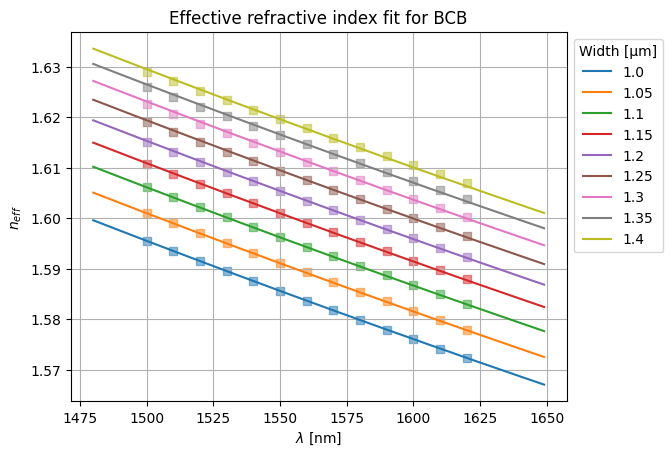

In [ ]:
# Create and effective index model for the waveguides as a funcion of wavelength and width
dneff_train = dneff
neff_train = n_eff[0]
wavelength_train = wavelength
width_train = width

wavelength_test = np.arange(1480, 1650, 1)

for i, w in enumerate(width):
    width_test = w
    neff_valid = n_eff[i]

    mse, neff_test, popt_w, popt_wl = neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid)

    fit, = plt.plot(wavelength_test, neff_test, label = f'{width_test}')
    plt.scatter(wavelength, neff_valid, color = fit.get_color(), alpha=0.5, marker='s')
    
plt.title(fr'Effective refractive index fit for {material}')
plt.xlabel(r'$\lambda$ [nm]')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend(fontsize = 10, title='Width [μm]', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:
# Obtain the grating period for each U1 Bragg grating
n1_array = []
n2_array = []
wl_array = []

i = 1 # Start with a corrugation of 25 nm
for i, bragg_wl in enumerate(wl_u1):
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    wl_array.append(float(np.round(period_array_u1[i]*1e3*2*n_avg, 2)))
    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    
    i+=1

print('U1 Test')
print(f'Original  λ   = {wl_u1} (nm)')
print(f'Result λ   = {wl_array} (nm)')
print(f'Δλ   = {wl_array - wl_u1} (nm)')

U1 Test
Original  λ   = [1520 1530 1540 1550 1560 1570 1580 1590] (nm)
Result λ   = [1574.05, 1584.77, 1595.5, 1606.24, 1616.99, 1627.75, 1638.53, 1649.31] (nm)
Δλ   = [54.05 54.77 55.5  56.24 56.99 57.75 58.53 59.31] (nm)


In [ ]:
# Obtain the grating period for each U1 Bragg grating
n1_array = []
n2_array = []
wl_array = []

i = 1 # Start with a corrugation of 25 nm
for i, bragg_wl in enumerate(wl_u2):
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    wl_array.append(float(np.round(period_array_u2[i]*1e3*2*n_avg, 2)))
    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    
    i+=1

print('U1 Test')
print(f'Original  λ   = {wl_u2} (nm)')
print(f'Result λ   = {wl_array} (nm)')
print(f'Δλ   = {wl_array - wl_u2} (nm)')

U1 Test
Original  λ   = [1530 1540 1550 1560 1570 1580] (nm)
Result λ   = [1584.92, 1595.63, 1606.36, 1617.09, 1627.83, 1638.58] (nm)
Δλ   = [54.92 55.63 56.36 57.09 57.83 58.58] (nm)


In [ ]:
# Obtain the grating period for each U1 Bragg grating
n1_array = []
n2_array = []
wl_array = []

i = 1 # Start with a corrugation of 25 nm
for i, bragg_wl in enumerate(wl_u3):
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    wl_array.append(float(np.round(period_array_u3[i]*1e3*2*n_avg, 2)))
    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    
    i+=1

print('U1 Test')
print(f'Original  λ   = {wl_u3} (nm)')
print(f'Result λ   = {wl_array} (nm)')
print(f'Δλ   = {wl_array - wl_u3} (nm)')

U1 Test
Original  λ   = [1530 1540 1550 1560] (nm)
Result λ   = [1582.04, 1592.93, 1603.83, 1614.74] (nm)
Δλ   = [52.04 52.93 53.83 54.74] (nm)
